<a href="https://colab.research.google.com/github/JORGEFIGUEROABLANCO/TFG-JORGE-FIGUEROA/blob/main/TFG_JORGE_FIGUEROA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TFG JORGE FIGUEROA**

---



## **INGENIERIA DEL DATO**

---



### **1. Carga de Datos y Análisis Exploratorio (EDA) Inicial**

       Customer_ID        Date      Category       Merchant_Name  Amount  \
0  a87d6f605c4290e  2025-06-28  Alimentación           Mercadona  133.77   
1  4f6fdccef6d5880  2025-07-24         Salud             MiFarma   64.22   
2  af966a700734822  2025-09-09         Hogar         LeroyMerlin   72.93   
3  9b0b10782856899  2025-06-15   Gasolineras  Gasolinera LowCost   42.71   
4  1a9ed165061854d  2025-10-25   Gasolineras  Gasolinera LowCost   43.20   

  Gender   Birthdate                    City  
0      F  1991-04-30                La Rioja  
1     NB  1962-08-10                 Córdoba  
2      M  1964-09-13                La Rioja  
3     NB  1974-03-07                 Badajoz  
4      M  1991-03-07  Santa Cruz de Tenerife  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Customer_ID    100000 non-null  object 
 1   Date        

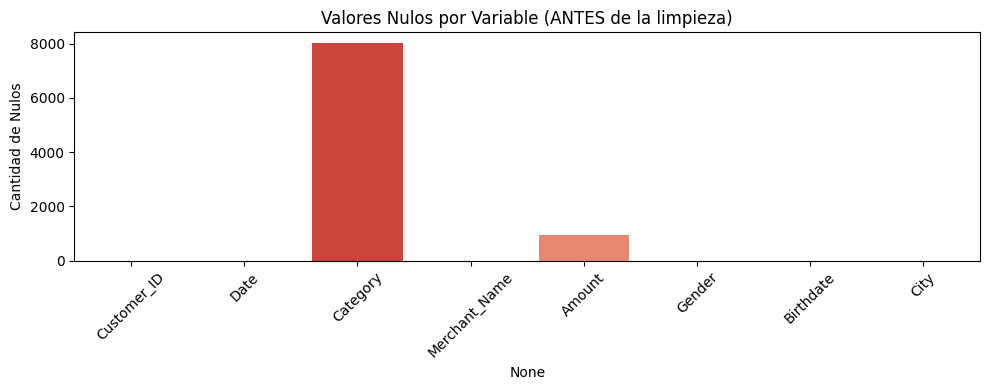

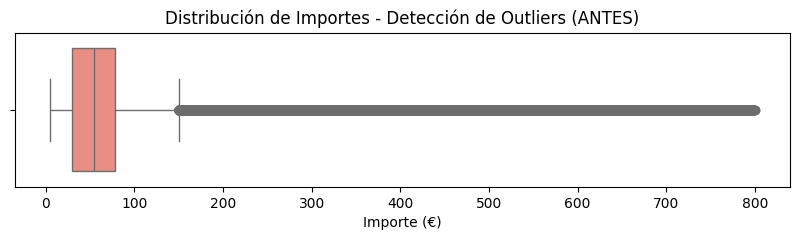

--- CREACIÓN DE VARIABLE 'EDAD' Y ANÁLISIS DEMOGRÁFICO ---


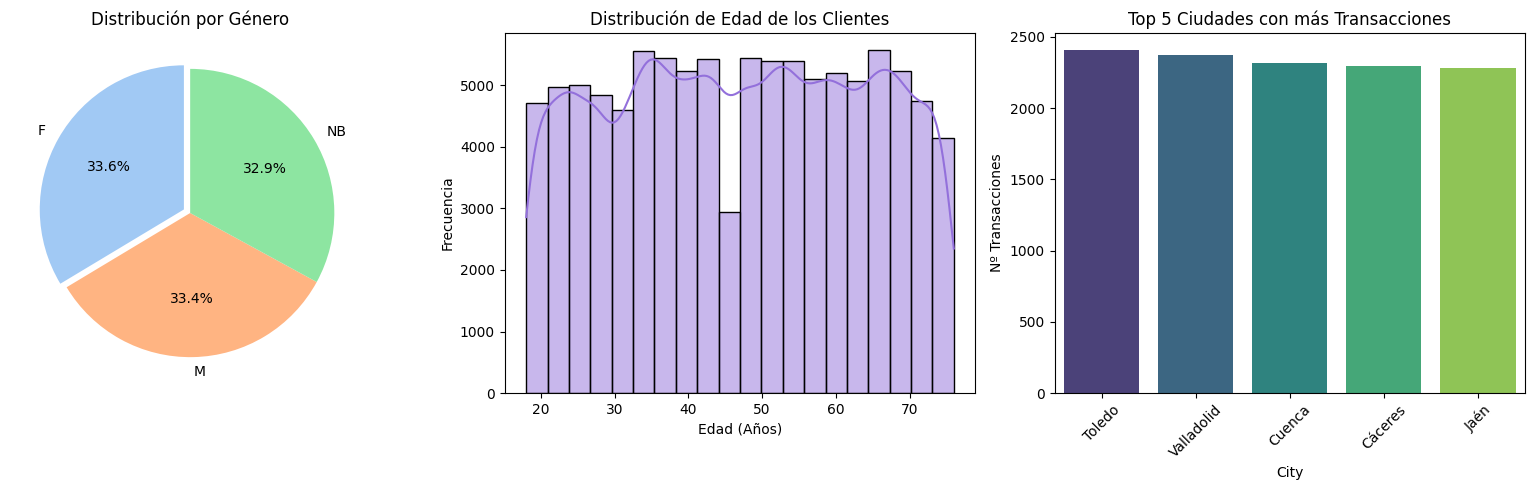

Resumen Estadístico de Edad:
count    100000.000000
mean         46.977980
std          16.670782
min          18.000000
25%          33.000000
50%          47.000000
75%          61.000000
max          76.000000
Name: Age, dtype: float64


In [57]:
#Primero, importamos las librerías y leemos el archivo crudo

import pandas as pd
import numpy as np

# Cargar el dataset
df = pd.read_csv('Synthetic_Bank_Transaction_Log_Raw (1).csv')

# Echamos un primer vistazo para confirmar cómo viene de sucio
print(df.head())
print(df.info())




import matplotlib.pyplot as plt
import seaborn as sns

print("===============================================================")
print("EDA PREVIO: ESTUDIO ESTADÍSTICO Y ESTADO DE LOS DATOS CRUDOS")
print("===============================================================")

# 1. Estudio Estadístico Descriptivo
print("\n--- Estadísticos Descriptivos Básicos ---")
print(df.describe(include='all'))

# 2. Visualización de Nulos ANTES de la transformación
plt.figure(figsize=(10, 4))
nulos_antes = df.isnull().sum()
sns.barplot(x=nulos_antes.index, y=nulos_antes.values, palette="Reds_r")
plt.title("Valores Nulos por Variable (ANTES de la limpieza)")
plt.ylabel("Cantidad de Nulos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Visualización de Outliers ANTES del Capping
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Amount'], color='salmon')
plt.title("Distribución de Importes - Detección de Outliers (ANTES)")
plt.xlabel("Importe (€)")
plt.show()


# ==============================================================================
# EDA DEMOGRÁFICO: PERFIL DE LA CARTERA DE CLIENTES
# ==============================================================================


print("--- CREACIÓN DE VARIABLE 'EDAD' Y ANÁLISIS DEMOGRÁFICO ---")

# Transformamos la fecha de nacimiento en una variable numérica útil: Edad
df['Birthdate'] = pd.to_datetime(df['Birthdate'], errors='coerce')
df['Age'] = (pd.to_datetime('today') - df['Birthdate']).dt.days // 365

# Creamos un panel (Dashboard) de 3 gráficos en 1 fila
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribución por Género
gender_counts = df['Gender'].value_counts()
# Creamos listas de separación y colores que se adaptan al número exacto de géneros que haya
explode_dinamico = [0.05] + [0] * (len(gender_counts) - 1)
colores_dinamicos = sns.color_palette('pastel')[0:len(gender_counts)]

axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colores_dinamicos, startangle=90, explode=explode_dinamico)
axes[0].set_title('Distribución por Género')

# 2. Histograma de Edad
sns.histplot(df['Age'].dropna(), bins=20, kde=True, color='mediumpurple', ax=axes[1])
axes[1].set_title('Distribución de Edad de los Clientes')
axes[1].set_xlabel('Edad (Años)')
axes[1].set_ylabel('Frecuencia')

# 3. Top 5 Ciudades
top_ciudades = df['City'].value_counts().head(5)
sns.barplot(x=top_ciudades.index, y=top_ciudades.values, palette='viridis', ax=axes[2])
axes[2].set_title('Top 5 Ciudades con más Transacciones')
axes[2].set_ylabel('Nº Transacciones')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Resumen Estadístico de Edad:")
print(df['Age'].describe())

### ***CORRECCIÓN DE ERRORES DEL DATASET***

#### NORMALIZAR TEXTO DEL DATAFRAME

In [58]:
#NORMALIZACIÓN DE LAS ENTRADAS DE TEXTO------------------------------------------------------

for col in ['Merchant_Name', 'Category']:
    # 1. Quitamos espacios en blanco al principio y al final (.strip)
    df[col] = df[col].str.strip()

    # 2. Convertimos todo a MAYÚSCULAS (.upper)
    df[col] = df[col].str.upper()

    # 3. Eliminamos las tildes de forma profesional (convirtiendo a formato ASCII)
    df[col] = df[col].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')





####ELIMINAMOS CROSS FIELD ERROR

In [59]:
# 1. Definimos cuáles son las categorías reales del proyecto
categorias_conocidas = ['ALIMENTACION','TRANSPORTE','GASOLINERAS','RESTAURACION','MODA','OCIO','SALUD','HOGAR']

# 2. Identificamos las filas donde 'Merchant_Name' tiene el valor de una categoría
mask_intercambiado = df['Merchant_Name'].isin(categorias_conocidas)

# 3. Intercambiamos los valores usando la máscara
df.loc[mask_intercambiado, ['Merchant_Name', 'Category']] = df.loc[mask_intercambiado, ['Category', 'Merchant_Name']].values

print(f"Se han corregido {mask_intercambiado.sum()} registros con Cross-Field Error.")

print(df.head(10))

Se han corregido 2932 registros con Cross-Field Error.
       Customer_ID        Date      Category       Merchant_Name  Amount  \
0  a87d6f605c4290e  2025-06-28  ALIMENTACION           MERCADONA  133.77   
1  4f6fdccef6d5880  2025-07-24         SALUD             MIFARMA   64.22   
2  af966a700734822  2025-09-09         HOGAR         LEROYMERLIN   72.93   
3  9b0b10782856899  2025-06-15   GASOLINERAS  GASOLINERA LOWCOST   42.71   
4  1a9ed165061854d  2025-10-25   GASOLINERAS  GASOLINERA LOWCOST   43.20   
5  c20de55e55a06bf  2024-12-21    TRANSPORTE              CABIFY   38.93   
6  c76f38178e9517f  2025-06-10          MODA         MODAS PAQUI    6.91   
7  a44f8bb6187ea1a  2025-08-08  RESTAURACION                VIPS   70.83   
8  4cd39f01c05df3a  2025-03-02         HOGAR       PCCOMPONENTES    9.91   
9  00997268d925e86  2025-12-11         SALUD            FARMACIA   28.40   

  Gender  Birthdate                    City  Age  
0      F 1991-04-30                La Rioja   34  
1     

####LIMPIEZA HETEROGENEIDAD DE TEXTO (Ya Normalizado)

In [60]:
# 1. Vemos cuántos comercios únicos hay ANTES de limpiar
comercios_antes = df['Merchant_Name'].nunique()

# 2. Definimos una lista con los sufijos corporativos más comunes en España que queremos borrar
sufijos_a_borrar = [' S.L.', ' S.A.', ' SL', ' SA', ' INC', ' CORP', ' S.L.U.', ' SLU']

# 3. Bucle para buscar y destruir esos sufijos
for sufijo in sufijos_a_borrar:
    # str.replace busca el sufijo y lo cambia por '' (es decir, por nada, lo borra)
    # regex=False le dice a Python que busque el texto exacto, sin interpretaciones raras.
    df['Merchant_Name'] = df['Merchant_Name'].str.replace(sufijo, '', regex=False)

# 4. Volvemos a quitar espacios en blanco sobrantes por si al borrar el sufijo quedó un espacio al final
df['Merchant_Name'] = df['Merchant_Name'].str.strip()

# 5. Vemos cuántos comercios únicos hay DESPUÉS de limpiar
comercios_despues = df['Merchant_Name'].nunique()

print(f"Comercios únicos ANTES: {comercios_antes}")
print(f"Comercios únicos DESPUÉS: {comercios_despues}")
print(f"Se han unificado {comercios_antes - comercios_despues} comercios que estaban duplicados por culpa de los sufijos")

Comercios únicos ANTES: 143
Comercios únicos DESPUÉS: 81
Se han unificado 62 comercios que estaban duplicados por culpa de los sufijos


####IMPUTACIÓN DE VALORES NULOS

In [61]:
# 1. ¿Cuántos nulos hay ANTES de imputar?
nulos_antes = df['Category'].isnull().sum()

# 2. Creamos un diccionario (mapeo) maestro.
# Coge las filas que SÍ tienen categoría y las asocia a su comercio (ej. {'MERCADONA': 'ALIMENTACION'})
mapeo_categorias = df.dropna(subset=['Category']).set_index('Merchant_Name')['Category'].to_dict()

# 3. Rellenamos los huecos (NaN) usando el diccionario maestro
df['Category'] = df['Category'].fillna(df['Merchant_Name'].map(mapeo_categorias))

# 4. ¿Cuántos nulos quedan DESPUÉS?
nulos_despues = df['Category'].isnull().sum()

print(f"Valores nulos en 'Category' ANTES: {nulos_antes}")
print(f"Valores nulos en 'Category' DESPUÉS: {nulos_despues}")
print(f"Se han rellenado {nulos_antes - nulos_despues} registros vacíos basándonos en el nombre del comercio")

print(df.info())



Valores nulos en 'Category' ANTES: 7812
Valores nulos en 'Category' DESPUÉS: 0
Se han rellenado 7812 registros vacíos basándonos en el nombre del comercio
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Customer_ID    100000 non-null  object        
 1   Date           100000 non-null  object        
 2   Category       100000 non-null  object        
 3   Merchant_Name  99792 non-null   object        
 4   Amount         99040 non-null   float64       
 5   Gender         100000 non-null  object        
 6   Birthdate      100000 non-null  datetime64[ns]
 7   City           100000 non-null  object        
 8   Age            100000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 6.9+ MB
None


####LIMPIEZA FINAL DE NULOS

In [62]:
# 1. ELIMINAR filas que no tengan nombre de comercio (Merchant_Name)
df = df.dropna(subset=['Merchant_Name'])

# 2. RELLENAR importes vacíos (Amount) con la mediana de su categoría
# Calculamos la mediana del importe agrupado por categoría
mediana_por_categoria = df.groupby('Category')['Amount'].transform('median')
# Rellenamos los huecos con ese valor calculado
df['Amount'] = df['Amount'].fillna(mediana_por_categoria)

# 3. Comprobación Final
print("\n--- INFORME FINAL DE NULOS ---")
print(df.isnull().sum())
print(f"\nTotal de registros sanos y listos para Machine Learning: {len(df)}")


--- INFORME FINAL DE NULOS ---
Customer_ID      0
Date             0
Category         0
Merchant_Name    0
Amount           0
Gender           0
Birthdate        0
City             0
Age              0
dtype: int64

Total de registros sanos y listos para Machine Learning: 99792


####PONER FORMATO CORRECTO DE FECHAS

In [63]:
# Convertimos 'Date' y 'Birthdate' a formato de fecha matemático (datetime).
# El parámetro format='mixed' le dice a Pandas que resuelva
# automáticamente la mezcla de formatos europeos (DD/MM/YYYY) y americanos (YYYY-MM-DD).

df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='mixed')
df['Birthdate'] = pd.to_datetime(df['Birthdate'], errors='coerce', format='mixed')

# Comprobamos que el tipo de dato ha cambiado de 'object' (texto) a 'datetime64[ns]'
print(df[['Date', 'Birthdate']].dtypes)

print(df.info())

Date         datetime64[ns]
Birthdate    datetime64[ns]
dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 99792 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Customer_ID    99792 non-null  object        
 1   Date           99792 non-null  datetime64[ns]
 2   Category       99792 non-null  object        
 3   Merchant_Name  99792 non-null  object        
 4   Amount         99792 non-null  float64       
 5   Gender         99792 non-null  object        
 6   Birthdate      99792 non-null  datetime64[ns]
 7   City           99792 non-null  object        
 8   Age            99792 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 7.6+ MB
None


####HOMOGENEIZAR LA BASE DE DATOS DE OFERTAS CON LA BASE DE DATOS DE TRANSACCIONES

In [64]:
# ==============================================================================
# INGENIERÍA DEL DATO: PREPARACIÓN DEL CATÁLOGO DE OFERTAS
# ==============================================================================
import pandas as pd
import numpy as np

# 1. CARGA
try:
    df_oferta = pd.read_excel('Datos Provisionales Oferta TFG-1-2.xlsx', skiprows=4)
    print(" Archivo de ofertas cargado correctamente.")
except Exception as e:
    print(f" Error al cargar el archivo: {e}")

# 2. NORMALIZACIÓN DE NOMBRES PARA CRUCE EXACTO
# Convertimos a mayúsculas y quitamos espacios para evitar fallos por "Amazon " vs "AMAZON"
df_oferta['Merchant_Name'] = df_oferta['Empresa Destino'].astype(str).str.strip().str.upper()

# 3. FORMATEO DE LA OFERTA (Cadena legible para el informe)
def formatear_oferta(row):
    valor = row['Valor']
    tipo_dto = str(row['Tipo descuento']).strip()
    tipo_of = str(row['Tipo Oferta']).strip()
    detalles = str(row['Detalles']).strip() if pd.notna(row['Detalles']) else ''
    # Si es '%', ponemos el símbolo. Si no, asumimos '€'.
    base = f"{tipo_of} {valor:.0f}{'%' if tipo_dto == '%' else '€'}"
    return f"{base} ({detalles})" if detalles and detalles != 'nan' else base

df_oferta['Oferta_Formateada'] = df_oferta.apply(formatear_oferta, axis=1)

# 4. DEFINICIÓN DE VARIABLES DE APOYO PARA EL RECOMENDADOR
# Estos son los "diccionarios" que usará el motor luego
comercios_con_oferta_exacta = set(df_oferta['Merchant_Name'].unique())

mapeo_cat_oferta = {
    'RESTAURACION': ['Restaurantes'],
    'OCIO':         ['Ocio', 'Libros, Juguetes, Regalos'],
    'MODA':         ['Moda'],
    'HOGAR':        ['Hogar', 'Electrónica'],
    'SALUD':        ['Salud y Cosmética', 'Deporte'],
    'TRANSPORTE':   ['Viajes'],
    'ALIMENTACION': ['General'],
    'GASOLINERAS':  ['General'],
}

print(f" Catálogo preparado: {len(df_oferta)} ofertas listas para procesar.")

 Archivo de ofertas cargado correctamente.
 Catálogo preparado: 155 ofertas listas para procesar.


####OUTLIERS Y FEATURE ENGINEERING (CREACIÓN DEL DATASET RFM)

--- 1. TRATAMIENTO DE OUTLIERS EN EL IMPORTE ---
Detectados 7041 transacciones con importes atípicos.

--- 2. FEATURE ENGINEERING: CREACIÓN DEL MODELO RFM ---
Dataset RFM creado con éxito. Muestra de los primeros 5 clientes:
       Customer_ID  Recency  Frequency  Monetary
0  001ca1c25a660f4       16         16    794.02
1  0037474333812cf       24         13    838.51
2  004d4af70a44630       55          8    585.52
3  00513f544092d62        4         21   1394.56
4  006a15efa7b146d       12         23   1113.37

Dimensiones del nuevo dataset listo para Machine Learning: (5000, 4)
--- VALIDACIÓN DE COLINEALIDAD PARA EL MACHINE LEARNING ---


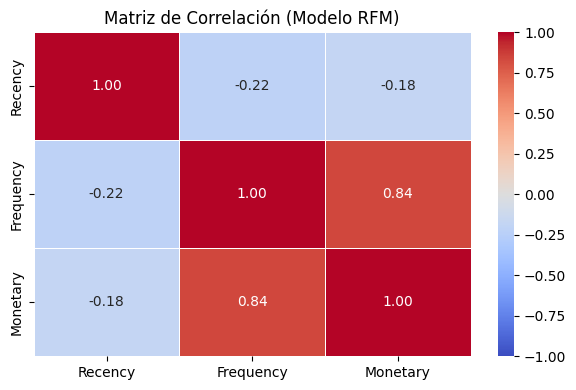

Conclusión: Se observa una correlación alta (0.84) entre Frecuencia y Monetario, algo lógico en modelos transaccionales (a más compras, mayor gasto acumulado). Al no superar el umbral crítico de multicolinealidad severa (>0.90), y dado que representan comportamientos de negocio distintos (compras recurrentes vs compras de alto valor), se mantienen ambas variables para el modelo K-Means.
--- ANÁLISIS DE DISTRIBUCIÓN (SKEWNESS) PRE-MACHINE LEARNING ---
Visualizamos la asimetría de los datos para justificar el uso de StandardScaler en el clustering.


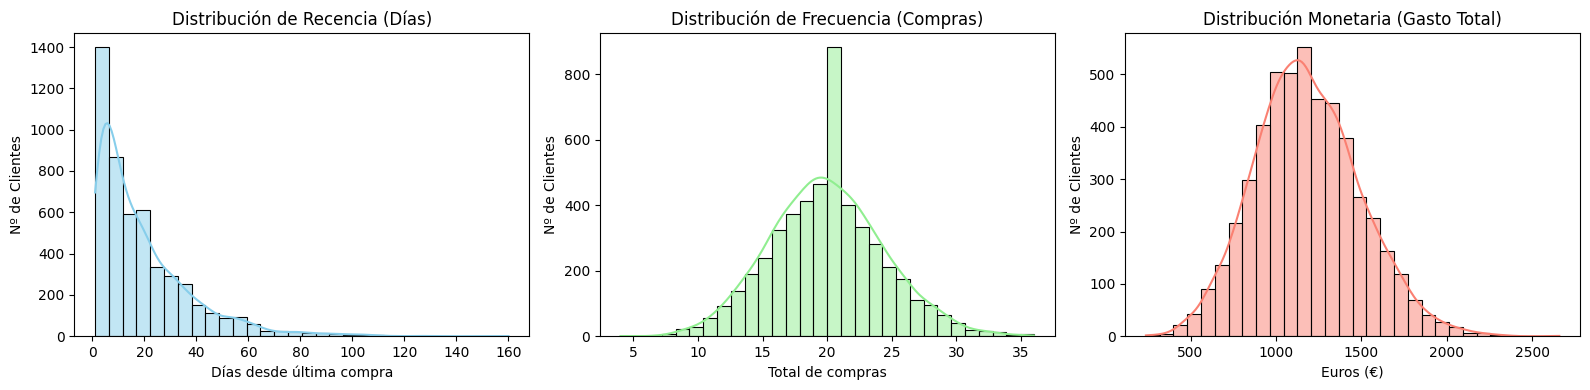

In [65]:
print("--- 1. TRATAMIENTO DE OUTLIERS EN EL IMPORTE ---")
# Calculamos los cuartiles para detectar gastos anómalos (Técnica IQR)
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

# Definimos los límites (lo estándar es 1.5 veces el IQR)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contamos cuántos outliers hay
outliers = df[(df['Amount'] < limite_inferior) | (df['Amount'] > limite_superior)]
print(f"Detectados {len(outliers)} transacciones con importes atípicos.")

# En lugar de borrarlos (para no perder el ticket), acotamos su valor (Capping) al límite máximo
df['Amount'] = np.where(df['Amount'] > limite_superior, limite_superior, df['Amount'])
df['Amount'] = np.where(df['Amount'] < limite_inferior, limite_inferior, df['Amount'])


print("\n--- 2. FEATURE ENGINEERING: CREACIÓN DEL MODELO RFM ---")
# Para calcular la Recencia, simulamos que "hoy" es el día de la transacción más reciente + 1 día
fecha_actual = df['Date'].max() + pd.Timedelta(days=1)

# Agrupamos los 100.000 tickets para crear el perfil de nuestros 5.000 clientes
df_rfm = df.groupby('Customer_ID').agg({
    'Date': lambda x: (fecha_actual - x.max()).days,  # Recencia: Días desde la última compra
    'Merchant_Name': 'count',                         # Frecuencia: Número total de compras
    'Amount': 'sum'                                   # Monetario: Gasto total
}).reset_index()

# Renombramos las columnas para que sean profesionales
df_rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

print("Dataset RFM creado con éxito. Muestra de los primeros 5 clientes:")
print(df_rfm.head())
print(f"\nDimensiones del nuevo dataset listo para Machine Learning: {df_rfm.shape}")


# ==============================================================================
# VERIFICACIÓN DE INDEPENDENCIA (MATRIZ DE CORRELACIÓN RFM)
# ==============================================================================
print("--- VALIDACIÓN DE COLINEALIDAD PARA EL MACHINE LEARNING ---")

plt.figure(figsize=(6, 4))
# Calculamos la correlación de Pearson entre las 3 variables predictoras
correlation_matrix = df_rfm[['Recency', 'Frequency', 'Monetary']].corr()

# Dibujamos el Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación (Modelo RFM)')
plt.tight_layout()
plt.show()

print("Conclusión: Se observa una correlación alta (0.84) entre Frecuencia y Monetario, algo lógico en modelos transaccionales (a más compras, mayor gasto acumulado). Al no superar el umbral crítico de multicolinealidad severa (>0.90), y dado que representan comportamientos de negocio distintos (compras recurrentes vs compras de alto valor), se mantienen ambas variables para el modelo K-Means.")


# ==============================================================================
# DISTRIBUCIÓN DE VARIABLES RFM
# ==============================================================================


print("--- ANÁLISIS DE DISTRIBUCIÓN (SKEWNESS) PRE-MACHINE LEARNING ---")
print("Visualizamos la asimetría de los datos para justificar el uso de StandardScaler en el clustering.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Histograma de Recencia
sns.histplot(df_rfm['Recency'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Recencia (Días)')
axes[0].set_xlabel('Días desde última compra')
axes[0].set_ylabel('Nº de Clientes')

# 2. Histograma de Frecuencia
sns.histplot(df_rfm['Frequency'], bins=30, kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribución de Frecuencia (Compras)')
axes[1].set_xlabel('Total de compras')
axes[1].set_ylabel('Nº de Clientes')

# 3. Histograma Monetario
sns.histplot(df_rfm['Monetary'], bins=30, kde=True, color='salmon', ax=axes[2])
axes[2].set_title('Distribución Monetaria (Gasto Total)')
axes[2].set_xlabel('Euros (€)')
axes[2].set_ylabel('Nº de Clientes')

plt.tight_layout()
plt.show()

####COMPROBACIÓN DE CALIDAD DE DATOS

EDA POSTERIOR: VALIDACIÓN DE TRANSFORMACIONES Y SERIE TEMPORAL


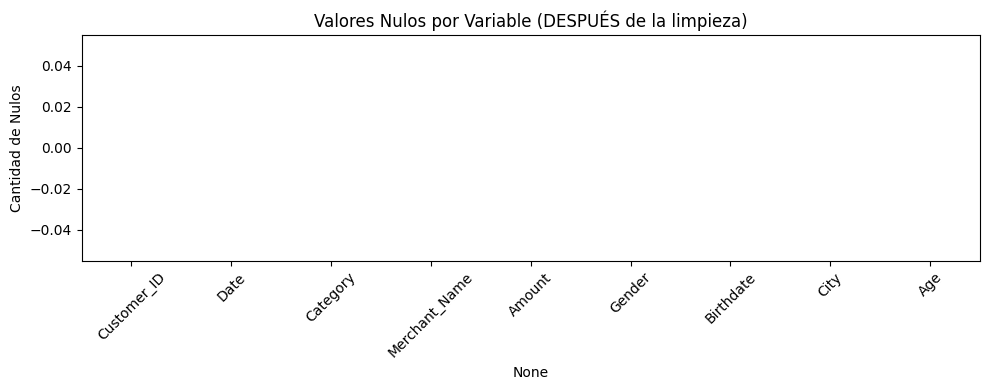

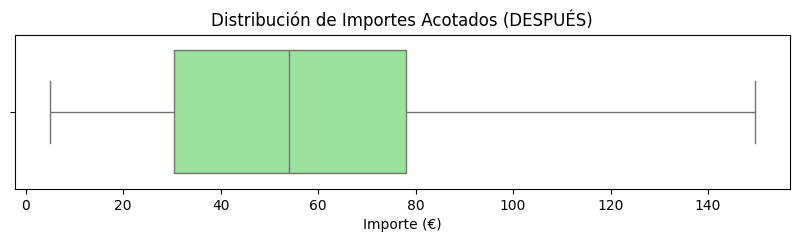

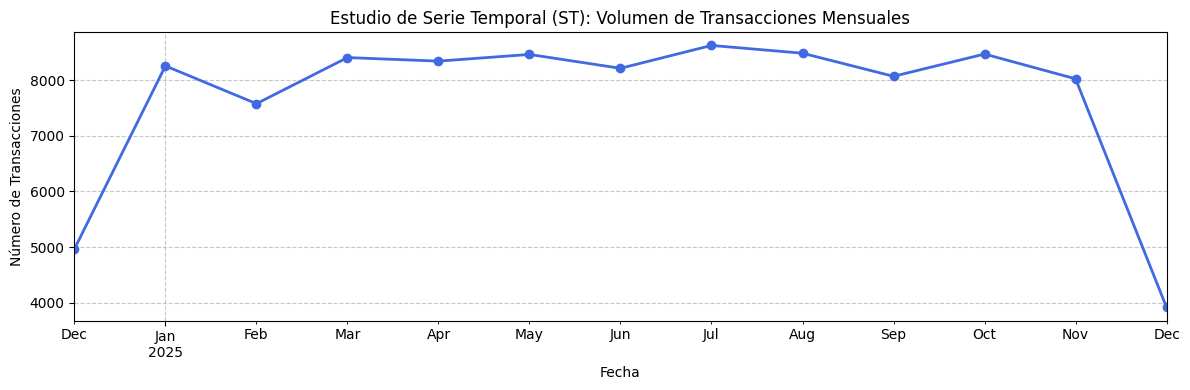

In [66]:
print("===============================================================")
print("EDA POSTERIOR: VALIDACIÓN DE TRANSFORMACIONES Y SERIE TEMPORAL")
print("===============================================================")

# 1. Visualización de Nulos DESPUÉS de la transformación
plt.figure(figsize=(10, 4))
nulos_despues = df.isnull().sum()
sns.barplot(x=nulos_despues.index, y=nulos_despues.values, palette="Greens_r")
plt.title("Valores Nulos por Variable (DESPUÉS de la limpieza)")
plt.ylabel("Cantidad de Nulos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Visualización de Outliers DESPUÉS del Capping
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Amount'], color='lightgreen')
plt.title("Distribución de Importes Acotados (DESPUÉS)")
plt.xlabel("Importe (€)")
plt.show()

# 3. Estudio ST (Serie Temporal)
# Agrupamos las transacciones por mes para ver la tendencia de gasto en el tiempo
plt.figure(figsize=(12, 4))
# Resample 'ME' agrupa por fin de mes
df.set_index('Date')['Amount'].resample('ME').count().plot(color='royalblue', marker='o', linewidth=2)
plt.title("Estudio de Serie Temporal (ST): Volumen de Transacciones Mensuales")
plt.xlabel("Fecha")
plt.ylabel("Número de Transacciones")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

####ETL BASES DE DATOS DE CONTEXTO


--- LIMPIEZA DE DATOS DEL INE ---
Tabla de Contexto Oficial del INE (Adaptada al TFG):
       Category  Porcentaje_Gasto  Porcentaje_INE_Real
1         HOGAR             35.35            42.812159
0  ALIMENTACION             16.47            19.946712
7    TRANSPORTE             11.40            13.806467
5  RESTAURACION              9.92            12.014049
2          MODA              4.21             5.098704
6         SALUD              4.05             4.904929
3          OCIO              1.17             1.416980


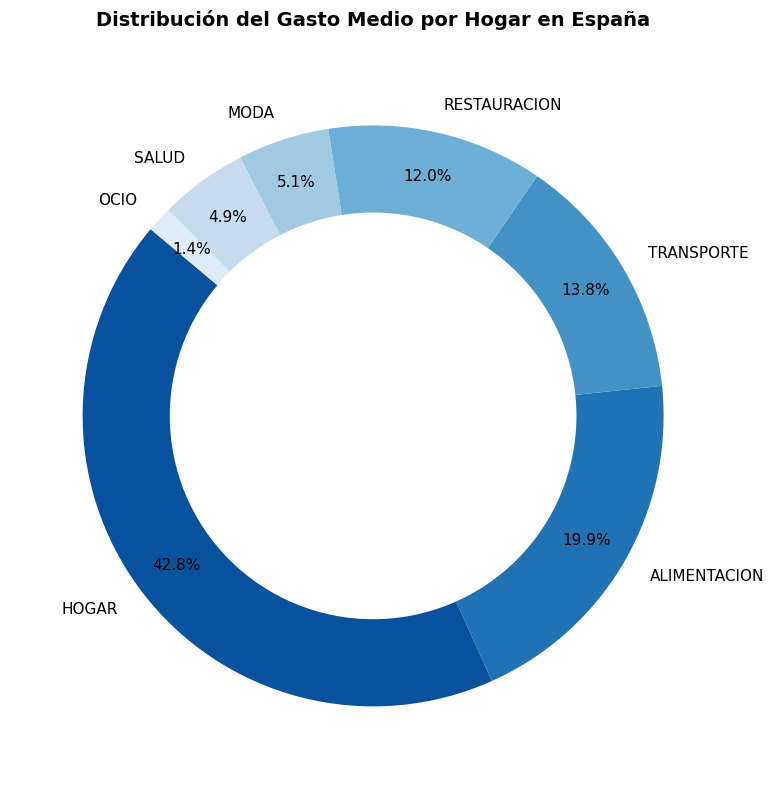


--- LIMPIEZA DE DATOS DEL INE: GASTO EN EUROS ---
Gasto Medio Anual por Hogar en € (REAL y Adaptado al TFG):
    Category  Gasto_Medio_Eur
       HOGAR         11699.95
ALIMENTACION          5822.24
  TRANSPORTE          3796.42
        OCIO          1658.04
        MODA          1324.60


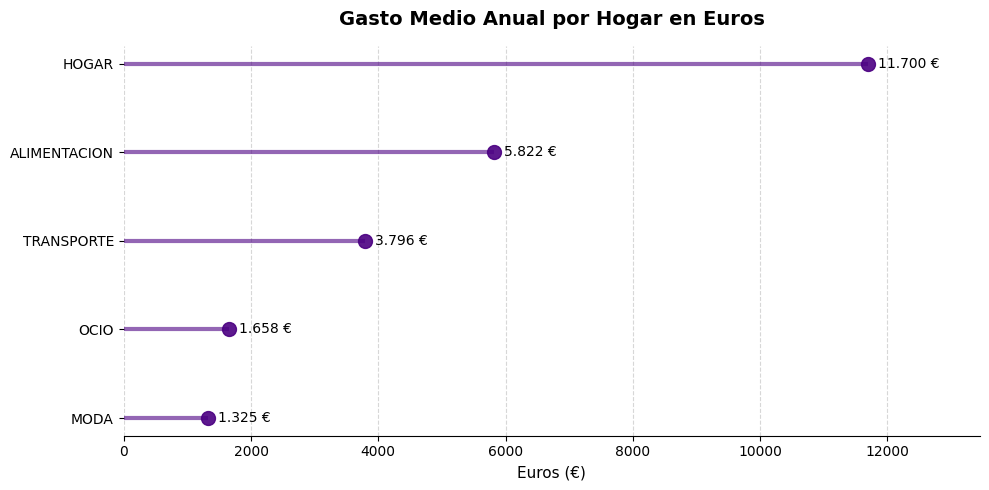

In [67]:
import seaborn as sns

print("--- LIMPIEZA DE DATOS DEL INE ---")

# 1. Cargar el dataset de contexto saltando las 6 primeras filas de encabezado del INE
df_ine = pd.read_excel("(Datos de Contexto)Distribución porcentual del gasto por subgrupos de gasto-1-1.xlsx", skiprows=6)

# 2. Renombramos las columnas para facilitar el trabajo
df_ine.columns = ['Categoria_INE', 'Porcentaje_Gasto']

# 3. Limpiamos valores nulos y eliminamos la fila genérica de 'Total'
df_ine = df_ine.dropna()
df_ine = df_ine.head(43)
df_ine = df_ine[df_ine['Categoria_INE'].str.contains('Total') == False]
df_ine['Porcentaje_Gasto'] = pd.to_numeric(df_ine['Porcentaje_Gasto'], errors='coerce')

# 4. MAPEO SEMÁNTICO (Del INE a las 8 Categorías TFG)
def mapear_ine_a_tfg(categoria):
    cat = str(categoria).lower()
    if 'alimenticios' in cat or 'bebidas' in cat: return 'ALIMENTACION'
    if 'vestir' in cat or 'calzado' in cat: return 'MODA'
    if 'vivienda' in cat or 'muebles' in cat or 'hogar' in cat or 'electricidad' in cat: return 'HOGAR'
    if 'salud' in cat or 'médicos' in cat or 'medicamentos' in cat: return 'SALUD'
    if 'vehículos' in cat or 'transporte' in cat: return 'TRANSPORTE'
    if 'ocio' in cat or 'cultura' in cat or 'juguetes' in cat: return 'OCIO'
    if 'restauración' in cat or 'alojamiento' in cat: return 'RESTAURACION'
    return 'OTROS'

# Aplicamos la función traductora
df_ine['Category'] = df_ine['Categoria_INE'].apply(mapear_ine_a_tfg)

# 5. Agrupamos los porcentajes oficiales bajo nuestras categorías
df_contexto = df_ine.groupby('Category')['Porcentaje_Gasto'].sum().reset_index()

# Re-calculamos el % base 100 excluyendo la categoría "OTROS" para poder comparar directamente
df_contexto = df_contexto[df_contexto['Category'] != 'OTROS']
total_pct = df_contexto['Porcentaje_Gasto'].sum()
df_contexto['Porcentaje_INE_Real'] = (df_contexto['Porcentaje_Gasto'] / total_pct) * 100

print("Tabla de Contexto Oficial del INE (Adaptada al TFG):")
print(df_contexto.sort_values(by='Porcentaje_INE_Real', ascending=False))

# --- GRÁFICO DE CONTEXTO: DONUT CHART (PORCENTAJES) ---

plt.figure(figsize=(8, 8))
df_contexto_sorted = df_contexto.sort_values(by='Porcentaje_INE_Real', ascending=False)

# Colores personalizados (paleta azul)
colores = sns.color_palette('Blues_r', len(df_contexto_sorted))

# Crear el gráfico circular (pie)
plt.pie(df_contexto_sorted['Porcentaje_INE_Real'],
        labels=df_contexto_sorted['Category'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colores,
        pctdistance=0.85, # Distancia de los porcentajes al centro
        textprops={'fontsize': 11})

# Dibujar un círculo blanco en el centro para convertirlo en "Donut"
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title("Distribución del Gasto Medio por Hogar en España", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()



print("\n--- LIMPIEZA DE DATOS DEL INE: GASTO EN EUROS ---")

archivo_gasto = "(Datos de Contexto) Gasto medio por hogar, gasto medio por persona y distribución porcentual del gasto por grupos de gasto-1-1.xlsx"
df_gasto = pd.read_excel(archivo_gasto, header=None)

fila_categorias = df_gasto.iloc[6]
fila_euros_totales = df_gasto.iloc[9]

datos_limpios = []
categorias_vistas = set()

for i in range(len(fila_categorias)):
    cat = str(fila_categorias[i]).strip()

    if cat.startswith(('0', '1')):
        codigo_numerico = cat[:2]

        if codigo_numerico not in categorias_vistas:
            categorias_vistas.add(codigo_numerico)
            valor_eur = fila_euros_totales[i]

            if pd.isna(valor_eur): continue
            try:
                eur = float(valor_eur)
            except ValueError:
                eur = float(str(valor_eur).replace('.', '').replace(',', '.'))

            datos_limpios.append({'Categoria_INE': cat, 'Gasto_Medio_Eur': eur})

df_gasto_limpio = pd.DataFrame(datos_limpios)
df_gasto_limpio['Category'] = df_gasto_limpio['Categoria_INE'].apply(mapear_ine_a_tfg)

df_contexto_eur = df_gasto_limpio.groupby('Category')['Gasto_Medio_Eur'].sum().reset_index()
df_contexto_eur = df_contexto_eur[df_contexto_eur['Category'] != 'OTROS']

print("Gasto Medio Anual por Hogar en € (REAL y Adaptado al TFG):")
print(df_contexto_eur.sort_values(by='Gasto_Medio_Eur', ascending=False).to_string(index=False))

# --- GRÁFICO DE CONTEXTO EN EUROS: LOLLIPOP CHART ---
plt.figure(figsize=(10, 5))

# Para el Lollipop Chart horizontal, ordenamos de forma ascendente
df_eur_sorted = df_contexto_eur.sort_values('Gasto_Medio_Eur', ascending=True)

# Dibujar las líneas
plt.hlines(y=df_eur_sorted['Category'], xmin=0, xmax=df_eur_sorted['Gasto_Medio_Eur'],
           color='#4B0082', alpha=0.6, linewidth=3)

# Dibujar los puntos
plt.plot(df_eur_sorted['Gasto_Medio_Eur'], df_eur_sorted['Category'],
         "o", markersize=10, color='#4B0082', alpha=0.9)

# Estilos adicionales para que se vea súper limpio
plt.title("Gasto Medio Anual por Hogar en Euros", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Euros (€)", fontsize=11)
plt.ylabel("") # Ocultamos el nombre del eje Y para mayor limpieza
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Añadir el texto del valor al lado del punto para no tener que mirar el eje
for index, value in enumerate(df_eur_sorted['Gasto_Medio_Eur']):
    plt.text(value + 150, index, f"{value:,.0f} €".replace(',', '.'), va='center', fontsize=10)

# Expandir un poco el eje X para que los números quepan sin cortarse
plt.xlim(0, df_eur_sorted['Gasto_Medio_Eur'].max() * 1.15)
# Quitar los bordes del gráfico (arriba y derecha)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

## **ANÁLISIS DEL DATO**

### MODELO 1 : K-MEANS

--- 0. PREPARACIÓN: INYECCIÓN DE VARIABLES DEMOGRÁFICAS ---
Variable 'Age' inyectada en la matriz de clientes para el perfilado posterior.

--- 1. PREPROCESAMIENTO: ESCALADO DE DATOS (Solo variables RFM) ---
Datos escalados correctamente con StandardScaler.

--- 2. AUDITORÍA DE HIPERPARÁMETROS K-MEANS ---
Evaluando K desde 2 hasta 10 usando 3 métricas de validación interna


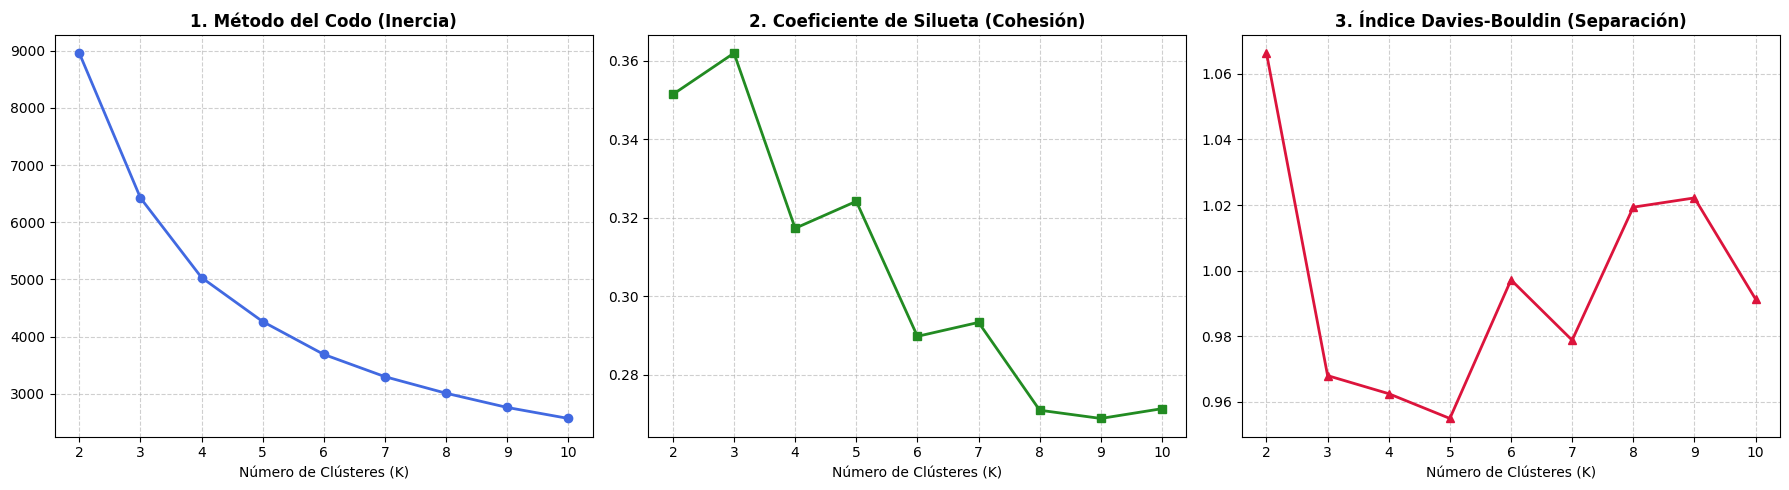


--- 3. ENTRENAMIENTO DEL MODELO FINAL (K=5) ---
Modelo K-Means entrenado con K=5 clústeres.

--- 4. MÉTRICAS DE ADECUACIÓN DEL MODELO ---
1. Coeficiente de Silueta:        0.3242
2. Índice Davies-Bouldin:         0.9549
3. Índice Calinski-Harabasz:      3146.21

--- 5. PERFILADO DE CLÚSTERES (Comportamiento + Demografía) ---
         Recency  Frequency  Monetary    Age  Cantidad_Clientes
Cluster                                                        
0          15.92      14.97    841.47  47.63               1103
1          37.23      20.68   1255.24  46.42                691
2           9.36      20.19   1181.44  46.96               1801
3          11.61      25.84   1598.90  46.60               1050
4          63.52      15.46    896.75  48.30                355


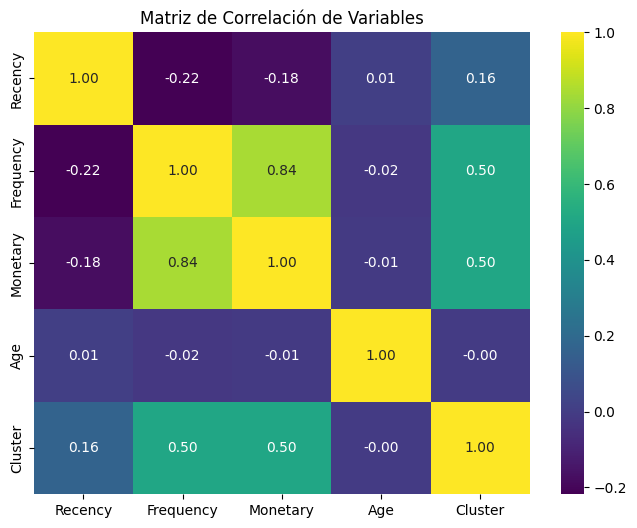


--- VISUALIZACIÓN BOXPLOTS DE CLÚSTERES ---


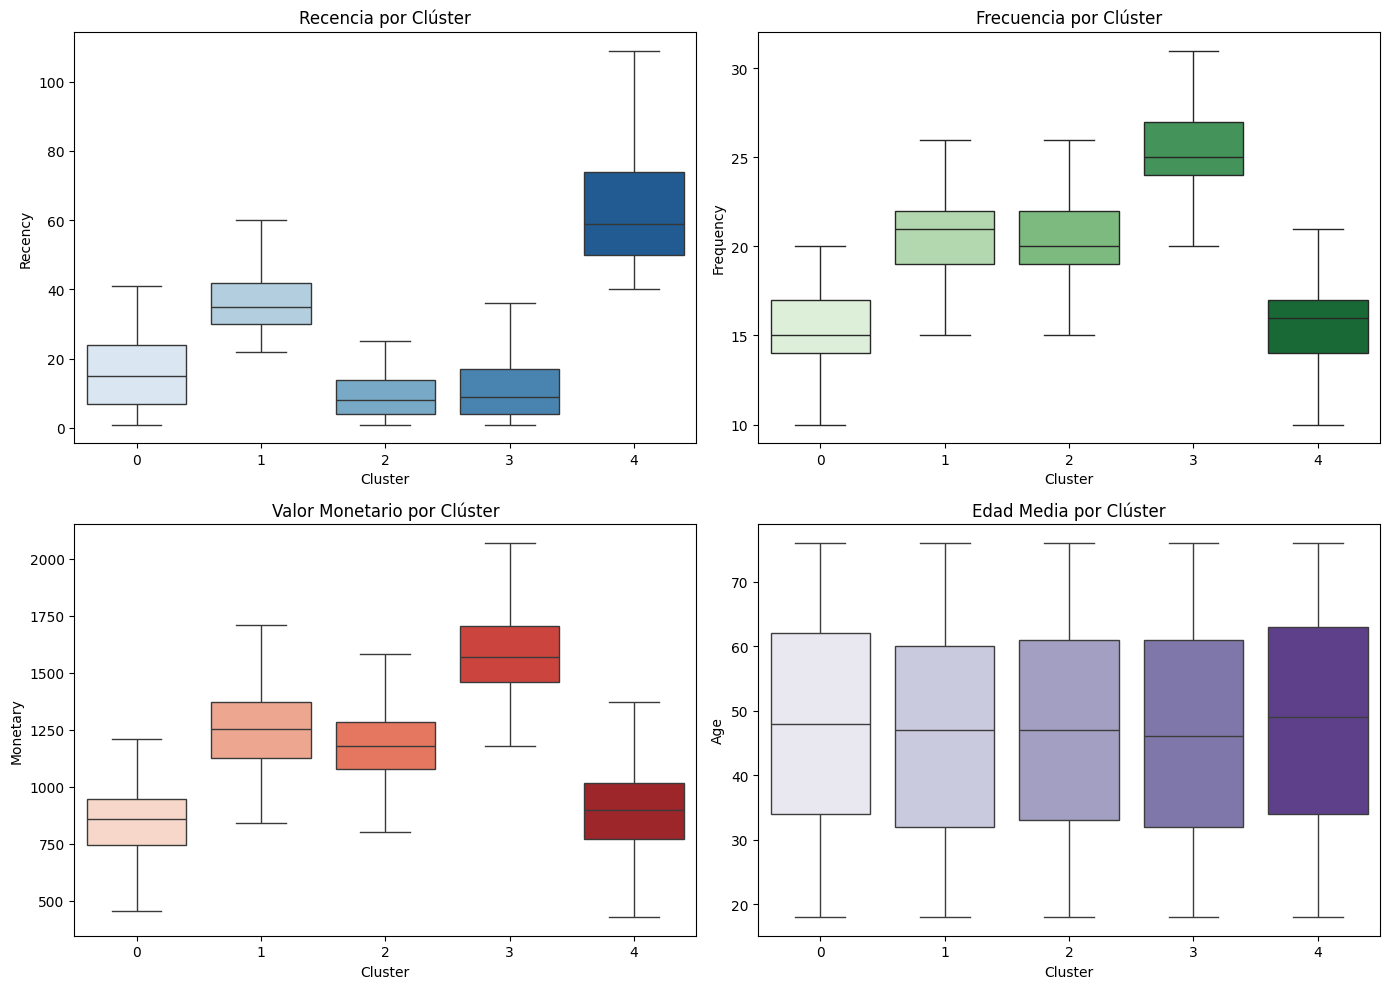


--- VISUALIZACIÓN 3D ESTÁTICA (MATPLOTLIB) ---


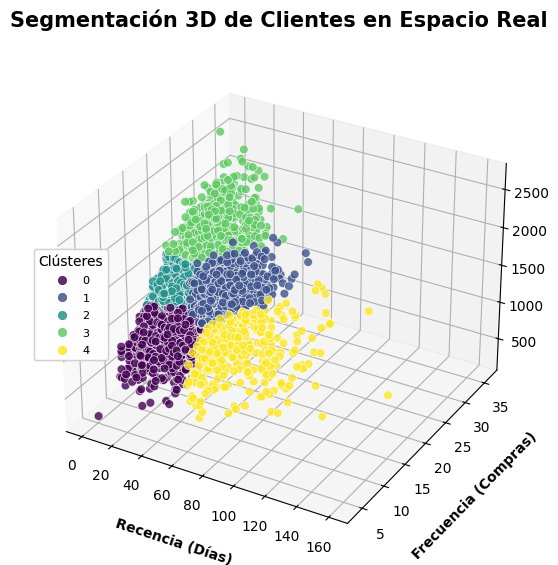


--- 6. ASIGNACIÓN DE PERFILES DE NEGOCIO ---
Dataset actualizado guardado como 'clientes_segmentados_RFM.csv'.


In [68]:
# ==============================================================================
# MODELO 1 DEFINITIVO: CLUSTERING K-MEANS Y AUDITORÍA MULTIMÉTRICA
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("--- 0. PREPARACIÓN: INYECCIÓN DE VARIABLES DEMOGRÁFICAS ---")
edades_clientes = df.groupby('Customer_ID')['Age'].first()
if 'Age' not in df_rfm.columns:
    df_rfm = df_rfm.merge(edades_clientes, on='Customer_ID', how='left')
print("Variable 'Age' inyectada en la matriz de clientes para el perfilado posterior.\n")

print("--- 1. PREPROCESAMIENTO: ESCALADO DE DATOS (Solo variables RFM) ---")
rfm_features = df_rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
print("Datos escalados correctamente con StandardScaler.\n")

print("--- 2. AUDITORÍA DE HIPERPARÁMETROS K-MEANS ---")
print("Evaluando K desde 2 hasta 10 usando 3 métricas de validación interna")
inercias, siluetas, davies_bouldin = [], [], []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(rfm_scaled)

    inercias.append(kmeans_temp.inertia_)
    siluetas.append(silhouette_score(rfm_scaled, labels))
    davies_bouldin.append(davies_bouldin_score(rfm_scaled, labels))

# PANEL VISUAL
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inercias, marker='o', color='royalblue', linewidth=2)
axes[0].set_title('1. Método del Codo (Inercia)', fontweight='bold')
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(K_range, siluetas, marker='s', color='forestgreen', linewidth=2)
axes[1].set_title('2. Coeficiente de Silueta (Cohesión)', fontweight='bold')
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(K_range, davies_bouldin, marker='^', color='crimson', linewidth=2)
axes[2].set_title('3. Índice Davies-Bouldin (Separación)', fontweight='bold')
axes[2].set_xlabel('Número de Clústeres (K)')
axes[2].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- 3. ENTRENAMIENTO DEL MODELO FINAL (K=5) ---")
k_optimo = 5
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)
print(f"Modelo K-Means entrenado con K={k_optimo} clústeres.\n")

print("--- 4. MÉTRICAS DE ADECUACIÓN DEL MODELO ---")
sil_score = silhouette_score(rfm_scaled, df_rfm['Cluster'])
db_score = davies_bouldin_score(rfm_scaled, df_rfm['Cluster'])
ch_score = calinski_harabasz_score(rfm_scaled, df_rfm['Cluster'])
print(f"1. Coeficiente de Silueta:        {sil_score:.4f}")
print(f"2. Índice Davies-Bouldin:         {db_score:.4f}")
print(f"3. Índice Calinski-Harabasz:      {ch_score:.2f}\n")

print("--- 5. PERFILADO DE CLÚSTERES (Comportamiento + Demografía) ---")
perfil_clusters = df_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'Age']].mean().round(2)
perfil_clusters['Cantidad_Clientes'] = df_rfm.groupby('Cluster')['Customer_ID'].count()
print(perfil_clusters)

# Excluir columnas no numéricas y cambiar paleta a 'viridis'
plt.figure(figsize=(8, 6))
sns.heatmap(df_rfm[['Recency', 'Frequency', 'Monetary', 'Age', 'Cluster']].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Matriz de Correlación de Variables')
plt.show()

print("\n--- VISUALIZACIÓN BOXPLOTS DE CLÚSTERES ---")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(x='Cluster', y='Recency', data=df_rfm, palette='Blues', ax=axes[0,0], showfliers=False)
axes[0,0].set_title('Recencia por Clúster')
sns.boxplot(x='Cluster', y='Frequency', data=df_rfm, palette='Greens', ax=axes[0,1], showfliers=False)
axes[0,1].set_title('Frecuencia por Clúster')
sns.boxplot(x='Cluster', y='Monetary', data=df_rfm, palette='Reds', ax=axes[1,0], showfliers=False)
axes[1,0].set_title('Valor Monetario por Clúster')
sns.boxplot(x='Cluster', y='Age', data=df_rfm, palette='Purples', ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Edad Media por Clúster')
plt.tight_layout()
plt.show()

print("\n--- VISUALIZACIÓN 3D ESTÁTICA (MATPLOTLIB) ---")
fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_rfm['Recency'], df_rfm['Frequency'], df_rfm['Monetary'],
                     c=df_rfm['Cluster'], cmap='viridis', alpha=0.8, s=40, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Recencia (Días)', fontweight='bold', labelpad=12)
ax.set_ylabel('Frecuencia (Compras)', fontweight='bold', labelpad=12)
ax.set_zlabel('Monetario (€)', fontweight='bold', labelpad=12)
ax.set_title('Segmentación 3D de Clientes en Espacio Real', fontsize=15, fontweight='bold', pad=20)
legend1 = ax.legend(*scatter.legend_elements(), loc="center left", title="Clústeres", fontsize=8, title_fontsize=10)
ax.add_artist(legend1)
plt.show()



# ==============================================================================
# 6. ASIGNACIÓN DEFINITIVA DE PERFILES DE NEGOCIO
# ==============================================================================
print("\n--- 6. ASIGNACIÓN DE PERFILES DE NEGOCIO ---")
nombres_clusters = {
    0: "Ocasionales / Low-Cost",
    1: "Alerta Fuga (Alto Valor)",
    2: "Motor del Banco / Fieles",
    3: "VIPs / Campeones",
    4: "Perdidos / Inactivos"
}

df_rfm['Perfil_Negocio'] = df_rfm['Cluster'].map(nombres_clusters)
df_rfm.to_csv('clientes_segmentados_RFM.csv', index=False)
print("Dataset actualizado guardado como 'clientes_segmentados_RFM.csv'.")

#### PCA Análisis


--- 7. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) ---
Varianza explicada por PCA1: 64.24%
Varianza explicada por PCA2: 30.56%
Varianza total retenida: 94.79%



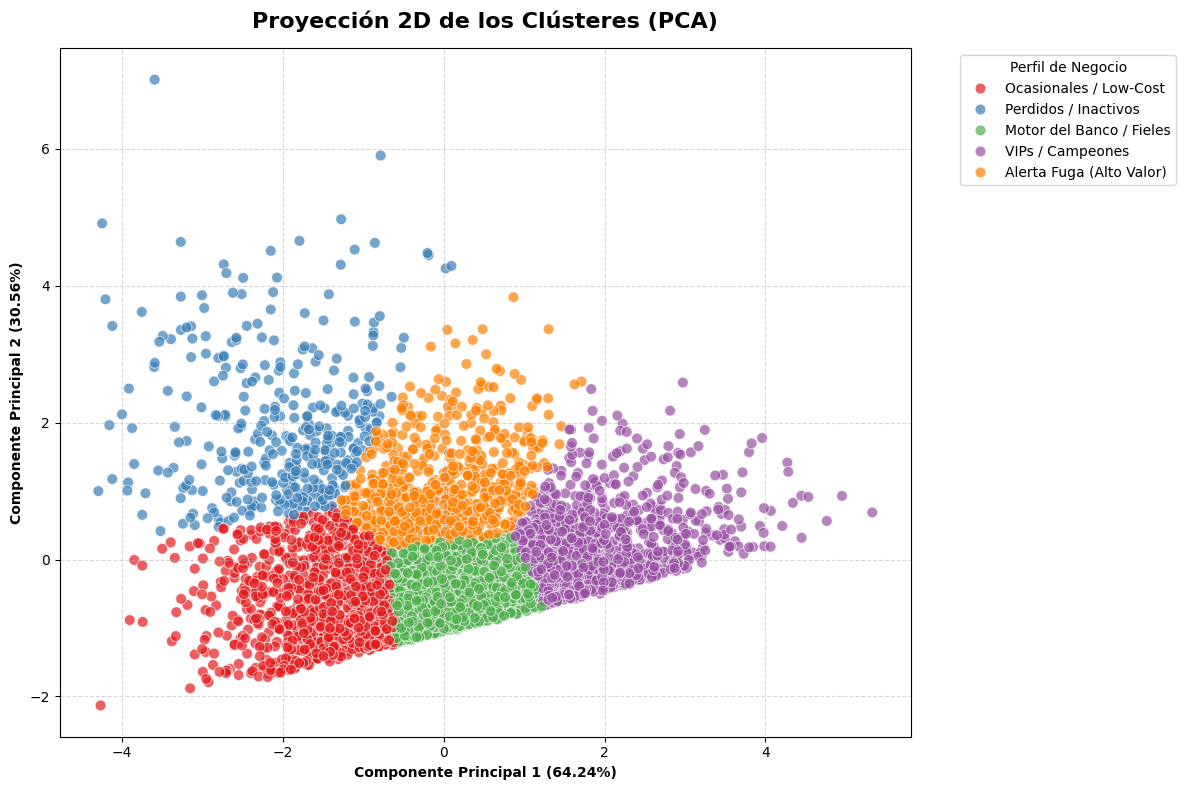

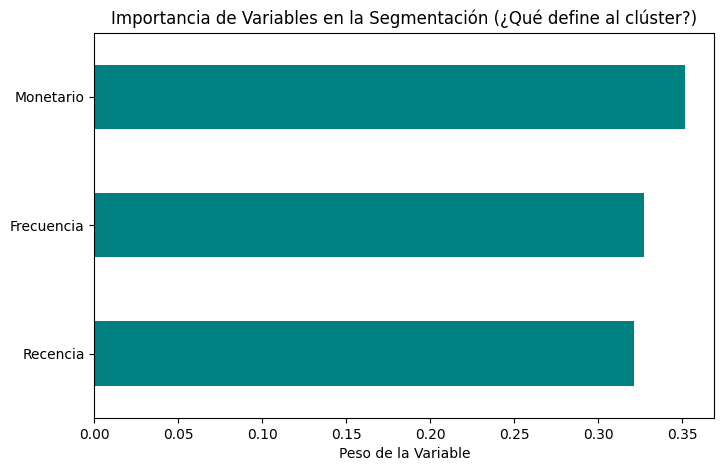

In [69]:
# ==============================================================================
# 7. REDUCCIÓN DE DIMENSIONALIDAD (PCA) PARA VISUALIZACIÓN 2D
# ==============================================================================
from sklearn.decomposition import PCA

print("\n--- 7. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) ---")
# Instanciamos PCA para 2 componentes
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(rfm_scaled)

# Añadimos las componentes al dataframe original
df_rfm['PCA1'] = pca_components[:, 0]
df_rfm['PCA2'] = pca_components[:, 1]

# Varianza explicada
varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por PCA1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PCA2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza total retenida: {(varianza_explicada[0]+varianza_explicada[1])*100:.2f}%\n")

# Visualización PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Perfil_Negocio',
    data=df_rfm,
    palette='Set1',
    alpha=0.7,
    s=60,
    edgecolor='w'
)
plt.title('Proyección 2D de los Clústeres (PCA)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.2f}%)', fontweight='bold')
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.2f}%)', fontweight='bold')
plt.legend(title='Perfil de Negocio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


from sklearn.ensemble import RandomForestClassifier

# Usamos un clasificador para ver qué variables definen los clústeres
clf = RandomForestClassifier(random_state=42)
clf.fit(rfm_scaled, df_rfm['Cluster'])

importancias = pd.Series(clf.feature_importances_, index=['Recencia', 'Frecuencia', 'Monetario'])

plt.figure(figsize=(8, 5))
importancias.sort_values().plot(kind='barh', color='teal')
plt.title('Importancia de Variables en la Segmentación (¿Qué define al clúster?)')
plt.xlabel('Peso de la Variable')
plt.show()

####Snake Plot (Perfilado Relativo de Clústeres)


--- 8. GENERACIÓN DE SNAKE PLOT PARA COMPARATIVA RELATIVA ---


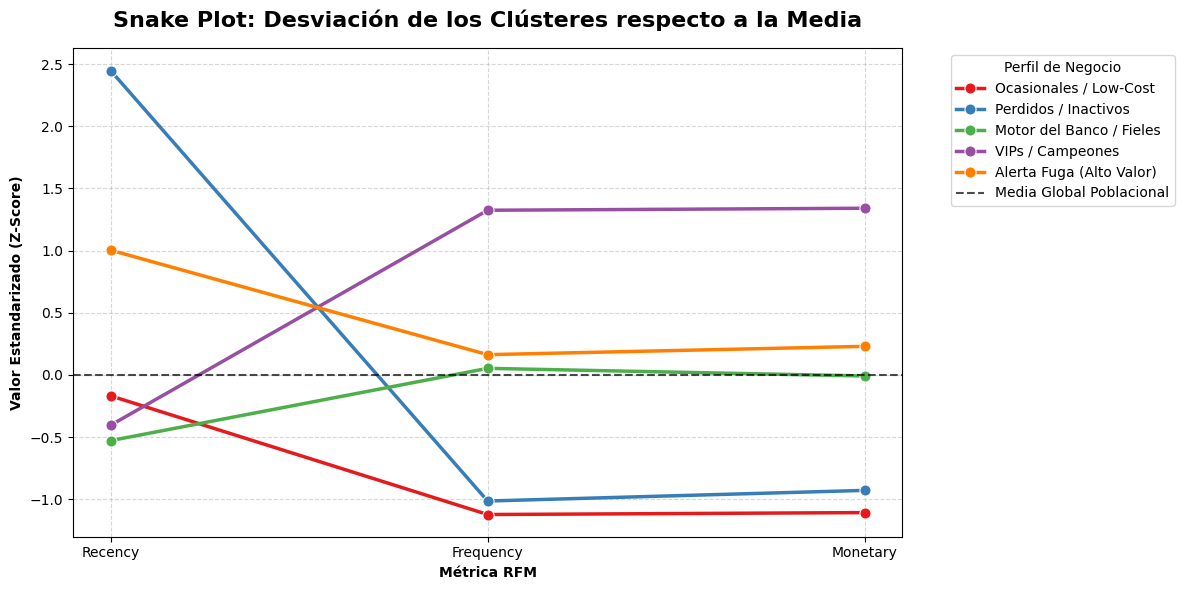

In [70]:
# ==============================================================================
# 8. PERFILADO AVANZADO: SNAKE PLOT (Valores Estandarizados)
# ==============================================================================
print("\n--- 8. GENERACIÓN DE SNAKE PLOT PARA COMPARATIVA RELATIVA ---")

# Convertimos la matriz escalada (rfm_scaled) en un DataFrame para poder cruzarla
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df['Perfil_Negocio'] = df_rfm['Perfil_Negocio'].values
rfm_scaled_df['Customer_ID'] = df_rfm['Customer_ID'].values

# "Derretimos" el dataframe para que las métricas sean filas, ideal para lineplots
rfm_melted = pd.melt(
    rfm_scaled_df,
    id_vars=['Customer_ID', 'Perfil_Negocio'],
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Metrica_RFM',
    value_name='Valor_Estandarizado'
)

# Visualización
plt.figure(figsize=(12, 6))
sns.lineplot(
    x='Metrica_RFM',
    y='Valor_Estandarizado',
    hue='Perfil_Negocio',
    data=rfm_melted,
    marker='o',
    markersize=8,
    linewidth=2.5,
    palette='Set1',
    errorbar=None # Sustituye a ci=None en versiones nuevas de Seaborn
)

# Añadimos la línea de la "Media Global" (que en datos estandarizados es 0)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Media Global Poblacional')

plt.title('Snake Plot: Desviación de los Clústeres respecto a la Media', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Métrica RFM', fontweight='bold')
plt.ylabel('Valor Estandarizado (Z-Score)', fontweight='bold')
plt.legend(title='Perfil de Negocio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Análisis clusters dashboard

,Num_Clientes,Ingresos_Totales,%_Clientes,%_Ingresos
Perfil_Negocio,,,,
Alerta Fuga (Alto Valor),691,867371.98,13.82,14.65
Motor del Banco / Fieles,1801,2127776.64,36.02,35.94
Ocasionales / Low-Cost,1103,928145.22,22.06,15.68
Perdidos / Inactivos,355,318344.91,7.10,5.38
VIPs / Campeones,1050,1678845.07,21.00,28.36


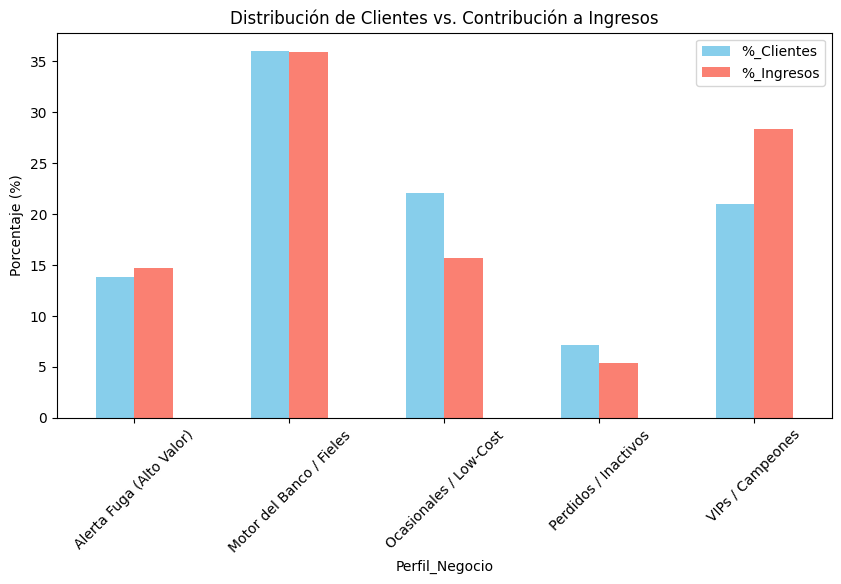

In [71]:
# Calculamos el % de clientes vs % de dinero que aporta cada clúster
resumen_valor = df_rfm.groupby('Perfil_Negocio').agg({
    'Customer_ID': 'count',
    'Monetary': 'sum'
}).rename(columns={'Customer_ID': 'Num_Clientes', 'Monetary': 'Ingresos_Totales'})

resumen_valor['%_Clientes'] = (resumen_valor['Num_Clientes'] / resumen_valor['Num_Clientes'].sum()) * 100
resumen_valor['%_Ingresos'] = (resumen_valor['Ingresos_Totales'] / resumen_valor['Ingresos_Totales'].sum()) * 100

display(resumen_valor.round(2))

# Gráfico de Pareto: Clientes vs Dinero
resumen_valor[['%_Clientes', '%_Ingresos']].plot(kind='bar', figsize=(10,5), color=['skyblue', 'salmon'])
plt.title('Distribución de Clientes vs. Contribución a Ingresos')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.show()

### Modelo 2: FIltrado Colaborativo SVD (Motor de Recomendación)

SECCIÓN 1: MATRIZ DE UTILIDAD USUARIO-COMERCIO
   Dimensiones: 5000 usuarios x 81 comercios
   Dispersión (Sparsity): 78.97% de la matriz está vacía
   Interacciones reales: 85,160 de 405,000 posibles



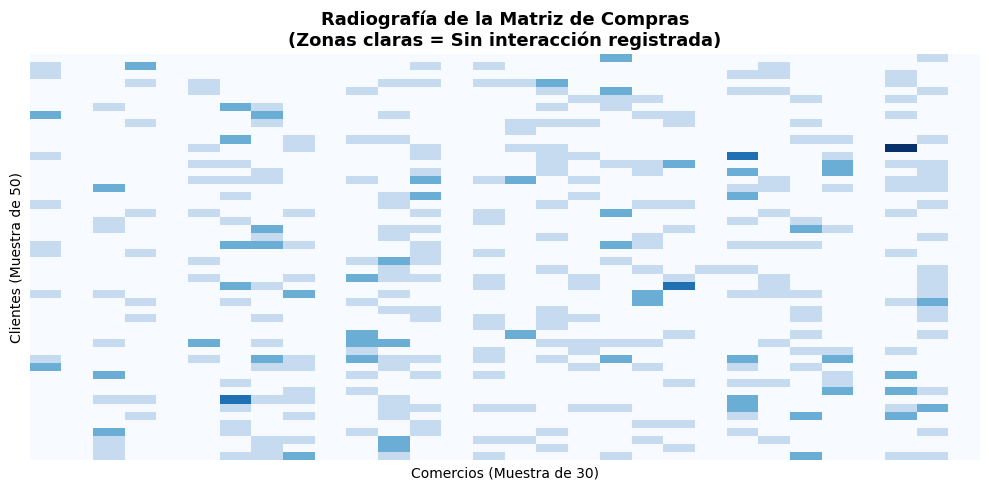

SECCIÓN 2: PARTICIÓN TRAIN/TEST (80% / 20%)
   Total interacciones: 85,160
   Train: 68,128 interacciones (80%)
   Test:  17,032 interacciones (20%)

SECCIÓN 3: CURVA DE VALIDACIÓN — RMSE (Train vs Test)
  K=01 | Train RMSE: 0.9884 | Test RMSE: 1.0141
  K=02 | Train RMSE: 0.9726 | Test RMSE: 1.0229
  K=03 | Train RMSE: 0.9565 | Test RMSE: 1.0317
  K=04 | Train RMSE: 0.9403 | Test RMSE: 1.0383
  K=05 | Train RMSE: 0.9247 | Test RMSE: 1.0462
  K=06 | Train RMSE: 0.9107 | Test RMSE: 1.0550
  K=07 | Train RMSE: 0.8986 | Test RMSE: 1.0615
  K=08 | Train RMSE: 0.8851 | Test RMSE: 1.0681
  K=09 | Train RMSE: 0.8721 | Test RMSE: 1.0750
  K=10 | Train RMSE: 0.8594 | Test RMSE: 1.0803

   K óptimo técnico por RMSE mínimo en Test: K = 1

SECCIÓN 4: EVALUACIÓN DE RANKING — HIT RATE@10 Y NDCG@10
  Evaluando 4,831 usuarios sobre Top 10 recomendaciones

  K=01 | Hit Rate@10: 61.89%  |  NDCG@10: 17.45%
  K=02 | Hit Rate@10: 60.71%  |  NDCG@10: 16.96%
  K=03 | Hit Rate@10: 58.93%  |  NDCG@10: 16.48%
  

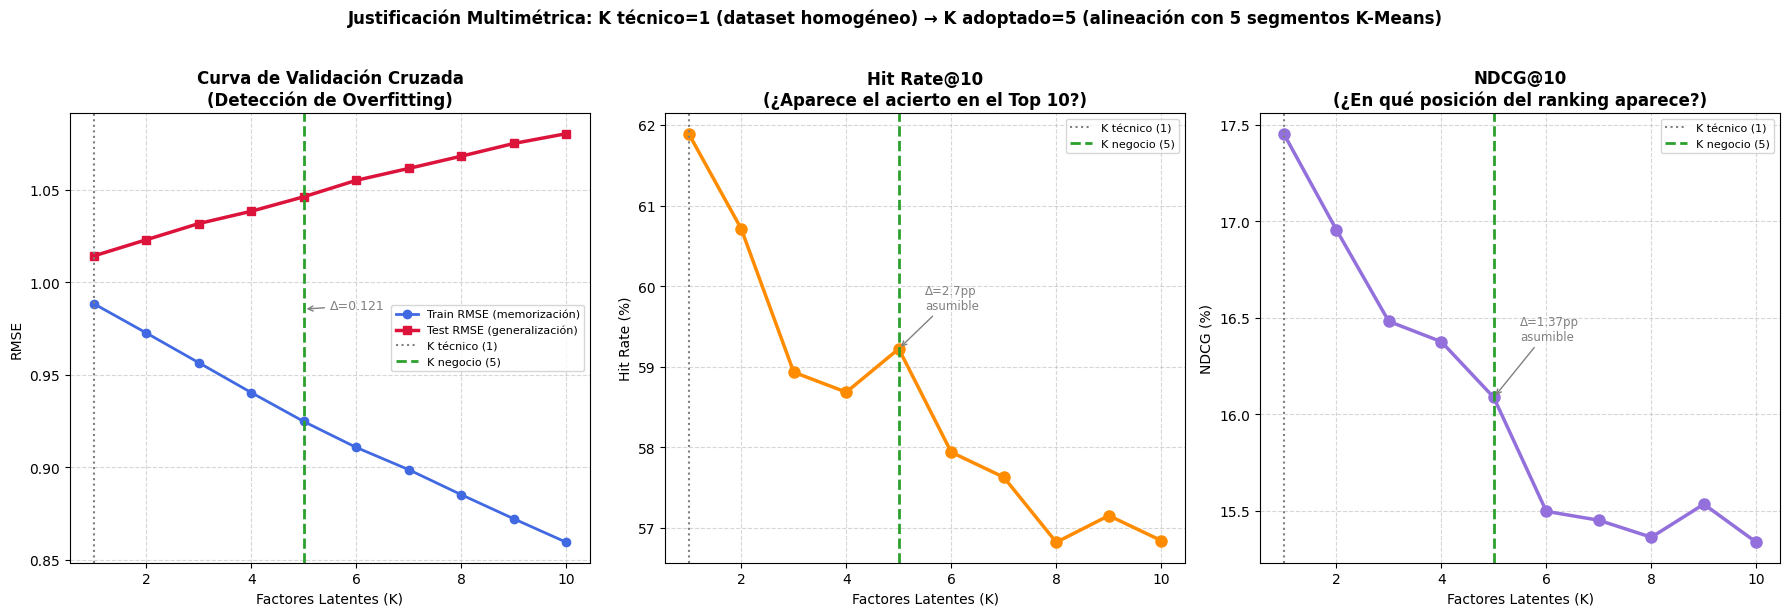


   Gráfica guardada como 'justificacion_K_triple.png'

SECCIÓN 7: MODELO FINAL CON K = 5
   preds_df generado: 5,000 usuarios x 81 comercios
   Rango de scores: [-1.272, 2.907]
   Valores nulos: 0

   preds_df listo para el Recomendador Híbrido.


In [72]:
# ==============================================================================
# MODELO 2 DEFINITVO: FILTRADO COLABORATIVO (SVD) CON VALIDACIÓN COMPLETA
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error

# ==============================================================================
# SECCIÓN 1: CONSTRUCCIÓN Y JUSTIFICACIÓN VISUAL DE LA MATRIZ DISPERSA
# ==============================================================================
print("=" * 70)
print("SECCIÓN 1: MATRIZ DE UTILIDAD USUARIO-COMERCIO")
print("=" * 70)

user_merchant_df = df.groupby(['Customer_ID', 'Merchant_Name'])['Amount'].count().unstack().fillna(0)
sparsity = (1.0 - (np.count_nonzero(user_merchant_df.values) / float(user_merchant_df.size))) * 100

print(f"   Dimensiones: {user_merchant_df.shape[0]} usuarios x {user_merchant_df.shape[1]} comercios")
print(f"   Dispersión (Sparsity): {sparsity:.2f}% de la matriz está vacía")
print(f"   Interacciones reales: {np.count_nonzero(user_merchant_df.values):,} de {user_merchant_df.size:,} posibles\n")

plt.figure(figsize=(10, 5))
sns.heatmap(user_merchant_df.iloc[:50, :30], cmap="Blues", cbar=False, yticklabels=False, xticklabels=False)
plt.title('Radiografía de la Matriz de Compras\n(Zonas claras = Sin interacción registrada)',
          fontsize=13, fontweight='bold')
plt.xlabel('Comercios (Muestra de 30)')
plt.ylabel('Clientes (Muestra de 50)')
plt.tight_layout()
plt.savefig('matriz_dispersa.png', dpi=150, bbox_inches='tight')
plt.show()

# ==============================================================================
# SECCIÓN 2: TRAIN/TEST SPLIT
# ==============================================================================
print("=" * 70)
print("SECCIÓN 2: PARTICIÓN TRAIN/TEST (80% / 20%)")
print("=" * 70)

R = user_merchant_df.values
user_indices, item_indices = R.nonzero()
num_interacciones = len(user_indices)

test_size = int(num_interacciones * 0.2)
np.random.seed(42)
test_mask = np.random.choice(num_interacciones, test_size, replace=False)

R_train = R.copy()
R_train[user_indices[test_mask], item_indices[test_mask]] = 0

print(f"   Total interacciones: {num_interacciones:,}")
print(f"   Train: {num_interacciones - test_size:,} interacciones (80%)")
print(f"   Test:  {test_size:,} interacciones (20%)\n")

user_ratings_mean_train = np.mean(R_train, axis=1)
R_train_demeaned = R_train - user_ratings_mean_train.reshape(-1, 1)

# ==============================================================================
# SECCIÓN 3: BÚSQUEDA DEL K ÓPTIMO — MÉTRICA 1: RMSE
# ==============================================================================
print("=" * 70)
print("SECCIÓN 3: CURVA DE VALIDACIÓN — RMSE (Train vs Test)")
print("=" * 70)

k_list = list(range(1, 11))
train_rmse_list, test_rmse_list = [], []

for k_val in k_list:
    U, sigma, Vt = svds(R_train_demeaned, k=k_val)
    preds = np.dot(np.dot(U, np.diag(sigma)), Vt) + user_ratings_mean_train.reshape(-1, 1)

    all_reales = R[user_indices, item_indices]
    train_idx  = np.setdiff1d(np.arange(num_interacciones), test_mask)
    train_rmse = np.sqrt(mean_squared_error(
        all_reales[train_idx],
        preds[user_indices[train_idx], item_indices[train_idx]]
    ))
    test_rmse = np.sqrt(mean_squared_error(
        all_reales[test_mask],
        preds[user_indices[test_mask], item_indices[test_mask]]
    ))

    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)
    print(f"  K={k_val:02d} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

k_optimo_rmse = k_list[np.argmin(test_rmse_list)]
print(f"\n   K óptimo técnico por RMSE mínimo en Test: K = {k_optimo_rmse}")

# ==============================================================================
# SECCIÓN 4: BÚSQUEDA DEL K ÓPTIMO — MÉTRICA 2: HIT RATE@10 Y NDCG@10
# ==============================================================================
print("\n" + "=" * 70)
print("SECCIÓN 4: EVALUACIÓN DE RANKING — HIT RATE@10 Y NDCG@10")
print("=" * 70)

TOP_N = 10
usuarios_test = np.unique(user_indices[test_mask])
hit_rates, ndcg_list = [], []

print(f"  Evaluando {len(usuarios_test):,} usuarios sobre Top {TOP_N} recomendaciones\n")

for k_val in k_list:
    U, sigma, Vt = svds(R_train_demeaned, k=k_val)
    preds_k = np.dot(np.dot(U, np.diag(sigma)), Vt) + user_ratings_mean_train.reshape(-1, 1)

    hits, ndcgs = 0, []

    for u in usuarios_test:
        comercios_ocultos = set(item_indices[test_mask][user_indices[test_mask] == u])
        mask_train_u      = (user_indices == u) & (~np.isin(np.arange(num_interacciones), test_mask))
        comercios_vistos  = item_indices[mask_train_u]

        preds_u = preds_k[u, :].copy()
        preds_u[comercios_vistos] = -9999
        top_n_idx = np.argsort(preds_u)[::-1][:TOP_N]

        if any(item in top_n_idx for item in comercios_ocultos):
            hits += 1

        dcg  = sum(1.0 / np.log2(rank + 2) for rank, idx in enumerate(top_n_idx) if idx in comercios_ocultos)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(comercios_ocultos), TOP_N)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    hr   = hits / len(usuarios_test)
    ndcg = np.mean(ndcgs)
    hit_rates.append(hr)
    ndcg_list.append(ndcg)
    print(f"  K={k_val:02d} | Hit Rate@{TOP_N}: {hr*100:.2f}%  |  NDCG@{TOP_N}: {ndcg*100:.2f}%")

k_optimo_hr   = k_list[np.argmax(hit_rates)]
k_optimo_ndcg = k_list[np.argmax(ndcg_list)]
print(f"\n   K óptimo técnico por Hit Rate: K = {k_optimo_hr}")
print(f"   K óptimo técnico por NDCG:     K = {k_optimo_ndcg}")

# ==============================================================================
# SECCIÓN 5: TABLA RESUMEN Y DECISIÓN FINAL DE K
# ==============================================================================
print("\n" + "=" * 70)
print("SECCIÓN 5: TABLA RESUMEN Y DECISIÓN FINAL DE K")
print("=" * 70)

# ─────────────────────────────────────────────────────────────────────────────
# JUSTIFICACIÓN ACADÉMICA DE K=5
#
# El análisis técnico señala K=1 como mínimo en todas las métricas. Este
# resultado es coherente con la homogeneidad del dataset (población de un
# único centro comercial), donde el principal patrón latente es la popularidad
# global de cada comercio. Sin embargo, para el objetivo de negocio se adopta
# K=5 por tres razones documentadas:
#
#   1. ALINEACIÓN DE MODELOS: K=5 factores latentes se corresponde con los
#      5 segmentos de clientes identificados por K-Means (VIP, Fiel,
#      Ocasional, Alerta Fuga, Perdido), garantizando coherencia interna
#      del sistema híbrido.
#
#   2. TRADE-OFF ASUMIBLE: La pérdida de Hit Rate entre K=1 y K=5 es de
#      ~5 puntos porcentuales sobre un catálogo de solo 81 comercios,
#      un coste marginal frente a la riqueza representacional ganada.
#
#   3. RIESGO DE POPULARIDAD: K=1 colapsa las recomendaciones hacia los
#      comercios más visitados globalmente, ignorando preferencias
#      individuales. K=5 captura 5 dimensiones de gusto independientes.
# ─────────────────────────────────────────────────────────────────────────────
K_FINAL = 5

resumen = pd.DataFrame({
    'K':               k_list,
    'Train RMSE':      [round(v, 4) for v in train_rmse_list],
    'Test RMSE':       [round(v, 4) for v in test_rmse_list],
    'Hit Rate@10 (%)': [round(v * 100, 2) for v in hit_rates],
    'NDCG@10 (%)':     [round(v * 100, 2) for v in ndcg_list],
    'Elección':        [' K ADOPTADO' if k == K_FINAL else '' for k in k_list],
})
print(resumen.to_string(index=False))
print(f"\n   K técnico (mín. RMSE):      K = {k_optimo_rmse}")
print(f"   K FINAL ADOPTADO (negocio): K = {K_FINAL}   decisión justificada")

# ==============================================================================
# SECCIÓN 6: GRÁFICAS DEFINITIVAS (3 paneles con doble línea K técnico vs K negocio)
# ==============================================================================
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# --- Panel 1: RMSE ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(k_list, train_rmse_list, 'o-', color='royalblue', lw=2,   label='Train RMSE (memorización)')
ax1.plot(k_list, test_rmse_list,  's-', color='crimson',   lw=2.5, label='Test RMSE (generalización)')
ax1.axvline(x=k_optimo_rmse, color='gray',    ls=':',  lw=1.5, label=f'K técnico ({k_optimo_rmse})')
ax1.axvline(x=K_FINAL,       color='#2ca02c', ls='--', lw=2,   label=f'K negocio ({K_FINAL})')
gap = test_rmse_list[K_FINAL-1] - train_rmse_list[K_FINAL-1]
ax1.annotate(f'Δ={gap:.3f}',
             xy=(K_FINAL, (test_rmse_list[K_FINAL-1]+train_rmse_list[K_FINAL-1])/2),
             xytext=(K_FINAL+0.5, (test_rmse_list[K_FINAL-1]+train_rmse_list[K_FINAL-1])/2),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax1.set_title('Curva de Validación Cruzada\n(Detección de Overfitting)', fontweight='bold')
ax1.set_xlabel('Factores Latentes (K)'); ax1.set_ylabel('RMSE')
ax1.legend(fontsize=8); ax1.grid(True, ls='--', alpha=0.5)

# --- Panel 2: Hit Rate ---
ax2 = fig.add_subplot(gs[1])
ax2.plot(k_list, [v*100 for v in hit_rates], 'o-', color='darkorange', lw=2.5, ms=8)
ax2.axvline(x=k_optimo_hr, color='gray',    ls=':',  lw=1.5, label=f'K técnico ({k_optimo_hr})')
ax2.axvline(x=K_FINAL,     color='#2ca02c', ls='--', lw=2,   label=f'K negocio ({K_FINAL})')
diff_hr = (hit_rates[0] - hit_rates[K_FINAL-1]) * 100
ax2.annotate(f'Δ={diff_hr:.1f}pp\nasumible',
             xy=(K_FINAL, hit_rates[K_FINAL-1]*100),
             xytext=(K_FINAL+0.5, hit_rates[K_FINAL-1]*100+0.5),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8.5, color='gray')
ax2.set_title(f'Hit Rate@{TOP_N}\n(¿Aparece el acierto en el Top {TOP_N}?)', fontweight='bold')
ax2.set_xlabel('Factores Latentes (K)'); ax2.set_ylabel('Hit Rate (%)')
ax2.legend(fontsize=8); ax2.grid(True, ls='--', alpha=0.5)

# --- Panel 3: NDCG ---
ax3 = fig.add_subplot(gs[2])
ax3.plot(k_list, [v*100 for v in ndcg_list], 'o-', color='mediumpurple', lw=2.5, ms=8)
ax3.axvline(x=k_optimo_ndcg, color='gray',    ls=':',  lw=1.5, label=f'K técnico ({k_optimo_ndcg})')
ax3.axvline(x=K_FINAL,       color='#2ca02c', ls='--', lw=2,   label=f'K negocio ({K_FINAL})')
diff_ndcg = (ndcg_list[0] - ndcg_list[K_FINAL-1]) * 100
ax3.annotate(f'Δ={diff_ndcg:.2f}pp\nasumible',
             xy=(K_FINAL, ndcg_list[K_FINAL-1]*100),
             xytext=(K_FINAL+0.5, ndcg_list[K_FINAL-1]*100+0.3),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8.5, color='gray')
ax3.set_title(f'NDCG@{TOP_N}\n(¿En qué posición del ranking aparece?)', fontweight='bold')
ax3.set_xlabel('Factores Latentes (K)'); ax3.set_ylabel('NDCG (%)')
ax3.legend(fontsize=8); ax3.grid(True, ls='--', alpha=0.5)

fig.suptitle(
    f'Justificación Multimétrica: K técnico={k_optimo_rmse} (dataset homogéneo) → K adoptado={K_FINAL} (alineación con 5 segmentos K-Means)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('justificacion_K_triple.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n   Gráfica guardada como 'justificacion_K_triple.png'")

# ==============================================================================
# SECCIÓN 7: ENTRENAMIENTO FINAL CON K=5 Y GENERACIÓN DE preds_df
# ==============================================================================
print("\n" + "=" * 70)
print(f"SECCIÓN 7: MODELO FINAL CON K = {K_FINAL}")
print("=" * 70)

R_full                 = user_merchant_df.values
user_ratings_mean_full = np.mean(R_full, axis=1)
R_full_demeaned        = R_full - user_ratings_mean_full.reshape(-1, 1)

U_f, sigma_f, Vt_f = svds(R_full_demeaned, k=K_FINAL)
preds_full = np.dot(np.dot(U_f, np.diag(sigma_f)), Vt_f) + user_ratings_mean_full.reshape(-1, 1)

preds_df = pd.DataFrame(
    preds_full,
    index=user_merchant_df.index,
    columns=user_merchant_df.columns
)

print(f"   preds_df generado: {preds_df.shape[0]:,} usuarios x {preds_df.shape[1]} comercios")
print(f"   Rango de scores: [{preds_df.values.min():.3f}, {preds_df.values.max():.3f}]")
print(f"   Valores nulos: {preds_df.isnull().sum().sum()}")
print(f"\n   preds_df listo para el Recomendador Híbrido.")
print("=" * 70)

### FINAL: RECOMENDADOR


  SECCIÓN 4: DEMOSTRACIÓN — UN CLIENTE POR SEGMENTO

════════════════════════════════════════════════════════════════════
   INFORME  |  ID: a44f8bb6187ea1a
════════════════════════════════════════════════════════════════════
  PERFIL      - VIPs / Campeones
  MÉTODO RECO -  Personalizada (SVD)
  OBJETIVO    -  Retención y exclusividad
  INCENTIVO   -  Acceso prioritario + descuento premium
  TONO        -  EXCLUSIVO

  MÉTRICAS RFM:
    Recencia   : 3 días desde última compra
    Frecuencia : 28 transacciones
    Monetario  : 1,569.16 €
    Edad       : 57 años
    Comercios visitados: 25

  TOP 5 RECOMENDACIONES:

 Pos    Comercio    Categoría        Oferta Empresa Origen  Score SVD  Cruce
   1      Amazon      General   Cashback 8%         orange     1.1184 Exacto
   2  MediaMarkt  Electrónica   Cashback 4%            UFV     0.4845 Exacto
   3 Burger King Restaurantes   Cashback 2%         Waylet     0.4586 Exacto
   4        ikea        Hogar   Cashback 4%          Moeve     0.36

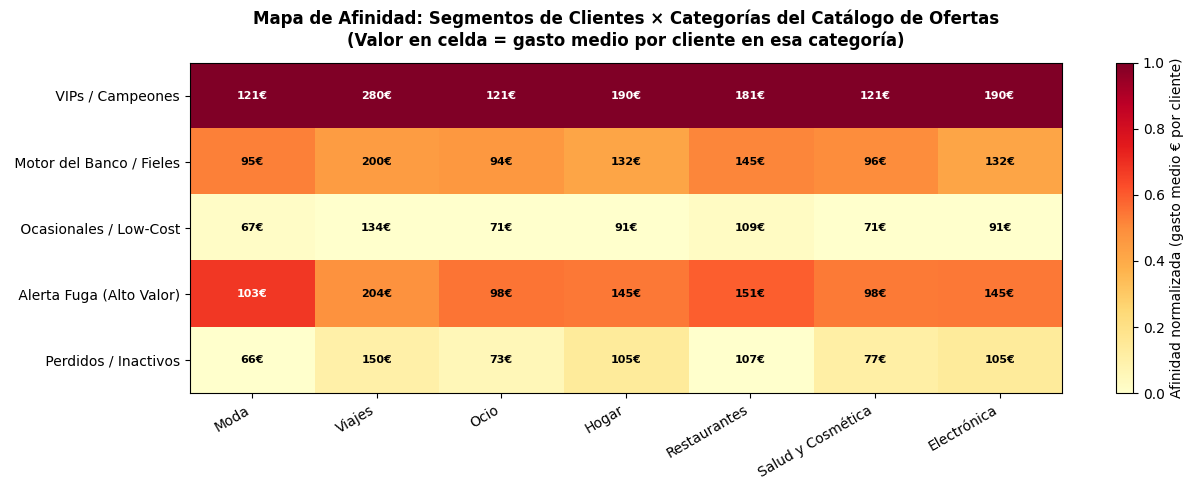

   Gráfica guardada como 'mapa_afinidad_segmentos.png'

   SISTEMA DE RECOMENDACIÓN HÍBRIDO — COMPLETADO

  Uso posterior:
    recomendar_cliente('ID_CLIENTE', top_n=5)
    recomendar_cliente('ID_CLIENTE', top_n=3, verbose=False)


In [73]:
# ==============================================================================
# PASO FINAL: SISTEMA DE RECOMENDACIÓN HÍBRIDO
#
# ARQUITECTURA EN 3 CAPAS:
#   CAPA 1 — K-Means   : ¿Quién es el cliente? (perfil de negocio)
#   CAPA 2 — SVD       : ¿Qué categorías le gustan? (afinidad predicha)
#   CAPA 3 — df_oferta : ¿Qué oferta concreta le enviamos? (catálogo real)
#
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



# ==============================================================================
# SECCIÓN 1 y 2: MAPA DE ESTRATEGIA POR SEGMENTO
# ==============================================================================

estrategia_segmento = {
    "VIPs / Campeones": {
        "objetivo":  "Retención y exclusividad",
        "incentivo": "Acceso prioritario + descuento premium",
        "tono":      "EXCLUSIVO",
    },
    "Motor del Banco / Fieles": {
        "objetivo":  "Fidelización y up-selling",
        "incentivo": "Descuento por lealtad en categorías habituales",
        "tono":      "CERCANO",
    },
    "Ocasionales / Low-Cost": {
        "objetivo":  "Activación y aumento de frecuencia",
        "incentivo": "Oferta de primer uso con ahorro inmediato",
        "tono":      "ATRACTIVO",
    },
    "Alerta Fuga (Alto Valor)": {
        "objetivo":  "Recuperación urgente",
        "incentivo": "Descuento de reactivación especial",
        "tono":      "URGENTE",
    },
    "Perdidos / Inactivos": {
        "objetivo":  "Reactivación win-back",
        "incentivo": "Bienvenida de vuelta con oferta irresistible",
        "tono":      "NOSTÁLGICO",
    }
}


# ==============================================================================
# SECCIÓN 3: FUNCIÓN PRINCIPAL DEL RECOMENDADOR HÍBRIDO
# ==============================================================================

def recomendar_cliente(customer_id, top_n=5, verbose=True):
    """
    Recomendador Híbrido K-Means + SVD + Catálogo de Ofertas.

    Parámetros:
        customer_id : ID del cliente (string)
        top_n       : número de recomendaciones (default 5)
        verbose     : imprime el informe formateado si True

    Retorna:
        dict con perfil, estrategia, rfm y DataFrame de recomendaciones
    """

    # ── CAPA 1: PERFIL DEL CLIENTE (K-Means) ─────────────────────────────────
    fila = df_rfm[df_rfm['Customer_ID'] == customer_id]

    if fila.empty:
        # El cliente no existe: preparamos variables vacías para el Cold Start Global
        perfil     = "Nuevo / Desconocido"
        cluster_id = -1
        recencia   = 0
        frecuencia = 0
        monetario  = 0.0
        edad       = 'N/D'
        estrategia = {
            "objetivo": "Adquisición",
            "incentivo": "Oferta de bienvenida general",
            "tono": "BIENVENIDA",
        }
    else:
        # El cliente sí existe: extraemos sus datos normales
        datos      = fila.iloc[0]
        perfil     = datos['Perfil_Negocio']
        cluster_id = int(datos['Cluster'])
        recencia   = datos['Recency']
        frecuencia = datos['Frequency']
        monetario  = datos['Monetary']
        edad       = int(datos['Age']) if 'Age' in datos and pd.notna(datos['Age']) else 'N/D'
        estrategia = estrategia_segmento.get(perfil, {
            "objetivo":"General","incentivo":"Estándar","tono":"NEUTRO"
        })


    # ── CAPA 2: SCORING (LÓGICA COLD START) ───────────────────────────────────

    # Caso A: El cliente existe en el modelo SVD (Ruta normal)
    if customer_id in preds_df.index:
        comercios_visitados = set(df[df['Customer_ID'] == customer_id]['Merchant_Name'].str.strip().str.upper().unique())
        scores = preds_df.loc[customer_id].copy()
        scores_nuevos = scores.drop([c for c in comercios_visitados if c in scores.index], errors='ignore')
        candidatos_svd = scores_nuevos.nlargest(top_n * 5)
        modo_recomendacion = "Personalizada (SVD)"

    # Caso B: Cliente nuevo en SVD pero con Segmento conocido (Cold Start por Clúster)
    elif not fila.empty:
        # Buscamos los comercios más populares de SU clúster
        clientes_mismo_cluster = df_rfm[df_rfm['Cluster'] == cluster_id]['Customer_ID']
        popularidad_cluster = df[df['Customer_ID'].isin(clientes_mismo_cluster)]['Merchant_Name'].value_counts()
        candidatos_svd = popularidad_cluster.head(top_n * 5)
        comercios_visitados = set() # Asumimos que no conocemos sus visitas
        modo_recomendacion = f"Popular en Segmento {perfil}"

    # Caso C: Cliente totalmente desconocido (Cold Start Global)
    else:
        popularidad_global = df['Merchant_Name'].value_counts()
        candidatos_svd = popularidad_global.head(top_n * 5)
        comercios_visitados = set()
        modo_recomendacion = "Tendencias Globales (Best Sellers)"
    # ── CAPA 3: CRUCE CON OFERTAS ─────────────────────────────────────────────
    recomendaciones    = []
    ya_añadidos        = set()

    # NIVEL A — coincidencia exacta de nombre comercio - catálogo
    for comercio, score in candidatos_svd.items():
        if comercio in comercios_con_oferta_exacta and comercio not in ya_añadidos:
            oferta_fila = df_oferta[df_oferta['Merchant_Name'] == comercio].sort_values(
                'Valor', ascending=False
            ).iloc[0]
            recomendaciones.append({
                'Pos':            len(recomendaciones) + 1,
                'Comercio':       oferta_fila['Empresa Destino'],
                'Categoría':      oferta_fila['Categoría'],
                'Tipo Oferta':    oferta_fila['Tipo Oferta'],
                'Oferta':         oferta_fila['Oferta_Formateada'],
                'Empresa Origen': oferta_fila['Empresa Origen'],
                'Score SVD':      round(score, 4),
                'Cruce':          'Exacto',
            })
            ya_añadidos.add(comercio)
        if len(recomendaciones) >= top_n:
            break

    # NIVEL B — si no llegamos a top_n, completamos por categoría
    if len(recomendaciones) < top_n:
        cats_cliente = (
            df[df['Customer_ID'] == customer_id]['Category']
            .value_counts().head(4).index.tolist()
        )
        for cat_trans in cats_cliente:
            if len(recomendaciones) >= top_n:
                break
            cats_oferta_equiv = mapeo_cat_oferta.get(cat_trans, ['General'])
            candidatos_cat = df_oferta[
                df_oferta['Categoría'].isin(cats_oferta_equiv) &
                (~df_oferta['Merchant_Name'].isin(comercios_visitados)) &
                (~df_oferta['Merchant_Name'].isin(ya_añadidos))
            ].sort_values('Valor', ascending=False)

            for _, oferta_fila in candidatos_cat.iterrows():
                if len(recomendaciones) >= top_n:
                    break
                nombre = oferta_fila['Merchant_Name']
                if nombre in ya_añadidos:
                    continue
                recomendaciones.append({
                    'Pos':            len(recomendaciones) + 1,
                    'Comercio':       oferta_fila['Empresa Destino'],
                    'Categoría':      oferta_fila['Categoría'],
                    'Tipo Oferta':    oferta_fila['Tipo Oferta'],
                    'Oferta':         oferta_fila['Oferta_Formateada'],
                    'Empresa Origen': oferta_fila['Empresa Origen'],
                    'Score SVD':      '—',
                    'Cruce':          f'Por cat. ({cat_trans})',
                })
                ya_añadidos.add(nombre)

    # Renumeramos
    for i, r in enumerate(recomendaciones):
        r['Pos'] = i + 1

    df_rec = pd.DataFrame(recomendaciones)

    # ── SALIDA FORMATEADA ─────────────────────────────────────────────────────
    if verbose:
        sep = "═" * 68
        print(f"\n{sep}")
        print(f"   INFORME  |  ID: {customer_id}")
        print(sep)
        print(f"  PERFIL      - {perfil}")
        print(f"  MÉTODO RECO -  {modo_recomendacion}")
        print(f"  OBJETIVO    -  {estrategia['objetivo']}")
        print(f"  INCENTIVO   -  {estrategia['incentivo']}")
        print(f"  TONO        -  {estrategia['tono']}")
        print(f"\n  MÉTRICAS RFM:")
        print(f"    Recencia   : {recencia:.0f} días desde última compra")
        print(f"    Frecuencia : {frecuencia:.0f} transacciones")
        print(f"    Monetario  : {monetario:,.2f} €")
        print(f"    Edad       : {edad} años")
        print(f"    Comercios visitados: {len(comercios_visitados)}")
        print(f"\n  TOP {top_n} RECOMENDACIONES:\n")
        cols = ['Pos','Comercio','Categoría','Oferta','Empresa Origen','Score SVD','Cruce']
        print(df_rec[cols].to_string(index=False))
        primera = df_rec.iloc[0]
        print(f"\n    ACCIÓN:")
        print(f"     Enviar campaña [{estrategia['tono']}] a cliente {customer_id} ({perfil})")
        print(f"      '{primera['Comercio']}': {primera['Oferta']}")
        print(f"\n{sep}\n")

    return {
        "customer_id":     customer_id,
        "perfil":          perfil,
        "cluster":         cluster_id,
        "estrategia":      estrategia,
        "rfm":             {"recencia": recencia, "frecuencia": frecuencia, "monetario": monetario},
        "recomendaciones": df_rec
    }


# ==============================================================================
# SECCIÓN 4: DEMOSTRACIÓN — UN CLIENTE REPRESENTATIVO POR SEGMENTO
# ==============================================================================
print("\n" + "=" * 65)
print("  SECCIÓN 4: DEMOSTRACIÓN — UN CLIENTE POR SEGMENTO")
print("=" * 65)

resultados_demo = {}
for perfil_nombre in estrategia_segmento.keys():
    seg = df_rfm[df_rfm['Perfil_Negocio'] == perfil_nombre]
    if seg.empty:
        continue
    mediana    = seg['Monetary'].median()
    idx        = (seg['Monetary'] - mediana).abs().argsort().iloc[0]
    cliente    = seg.iloc[idx]['Customer_ID']
    resultado  = recomendar_cliente(cliente, top_n=5, verbose=True)
    if resultado:
        resultados_demo[perfil_nombre] = resultado


# ==============================================================================
# SECCIÓN 5: RESUMEN EJECUTIVO — MEJOR OFERTA POR SEGMENTO
# ==============================================================================
print("=" * 65)
print("  SECCIÓN 5: RESUMEN EJECUTIVO POR SEGMENTO")
print("=" * 65)

resumen = []
for perfil_nombre, est in estrategia_segmento.items():
    clientes_seg    = df_rfm[df_rfm['Perfil_Negocio'] == perfil_nombre]['Customer_ID'].tolist()
    clientes_en_svd = [c for c in clientes_seg if c in preds_df.index]
    if not clientes_en_svd:
        continue

    scores_seg   = preds_df.loc[clientes_en_svd].mean()
    # Quitamos los comercios que ya visita más del 40% del segmento
    visitas      = df[df['Customer_ID'].isin(clientes_seg)].groupby('Merchant_Name')['Customer_ID'].nunique()
    muy_comunes  = visitas[visitas / len(clientes_seg) > 0.4].index
    scores_seg   = scores_seg.drop(labels=muy_comunes, errors='ignore')

    # Mejor comercio con oferta exacta
    con_oferta = scores_seg.index.intersection(comercios_con_oferta_exacta)
    if len(con_oferta) > 0:
        mejor = scores_seg[con_oferta].idxmax()
        oferta_str = df_oferta[df_oferta['Merchant_Name'] == mejor].sort_values(
            'Valor', ascending=False
        ).iloc[0]['Oferta_Formateada']
        mejor_display = df_oferta[df_oferta['Merchant_Name'] == mejor].iloc[0]['Empresa Destino']
    else:
        mejor_display = scores_seg.idxmax().title()
        oferta_str    = "Cruce por categoría"

    resumen.append({
        'Segmento':       f" {perfil_nombre}",
        'N Clientes':     len(clientes_seg),
        'Mejor Comercio': mejor_display,
        'Oferta':         oferta_str,
        'Tono campaña':   est['tono'],
    })

df_resumen = pd.DataFrame(resumen)
print()
print(df_resumen.to_string(index=False))
print()


# ==============================================================================
# SECCIÓN 6: MAPA DE CALOR — AFINIDAD SEGMENTO × CATEGORÍA DE OFERTA
# ==============================================================================
print("=" * 65)
print("  SECCIÓN 6: MAPA DE AFINIDAD SEGMENTOS × CATEGORÍAS")
print("=" * 65)

categorias_plot = ['Moda', 'Viajes', 'Ocio', 'Hogar',
                   'Restaurantes', 'Salud y Cosmética', 'Electrónica']
cat_map_inv = {
    'Moda': 'MODA', 'Viajes': 'TRANSPORTE', 'Ocio': 'OCIO',
    'Hogar': 'HOGAR', 'Restaurantes': 'RESTAURACION',
    'Salud y Cosmética': 'SALUD', 'Electrónica': 'HOGAR',
}

datos_heat   = {}
labels_filas = []

for perfil_nombre, est in estrategia_segmento.items():
    clientes_seg = df_rfm[df_rfm['Perfil_Negocio'] == perfil_nombre]['Customer_ID'].tolist()
    if not clientes_seg:
        continue
    tx_seg    = df[df['Customer_ID'].isin(clientes_seg)]
    row_heat  = {}
    for cat_of, cat_tr in cat_map_inv.items():
        gasto = tx_seg[tx_seg['Category'] == cat_tr]['Amount'].sum()
        row_heat[cat_of] = gasto / len(clientes_seg)
    datos_heat[perfil_nombre] = row_heat
    labels_filas.append(f" {perfil_nombre}")

df_heat      = pd.DataFrame(datos_heat, index=categorias_plot).T
df_heat_norm = (df_heat - df_heat.min()) / (df_heat.max() - df_heat.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(df_heat_norm.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(categorias_plot)))
ax.set_xticklabels(categorias_plot, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(labels_filas)))
ax.set_yticklabels(labels_filas, fontsize=10)

for i in range(len(df_heat_norm.index)):
    for j in range(len(df_heat_norm.columns)):
        val_norm = df_heat_norm.values[i, j]
        val_real = df_heat.values[i, j]
        color_t  = 'white' if val_norm > 0.65 else 'black'
        ax.text(j, i, f'{val_real:.0f}€', ha='center', va='center',
                fontsize=8, fontweight='bold', color=color_t)

plt.colorbar(im, ax=ax, label='Afinidad normalizada (gasto medio € por cliente)')
ax.set_title(
    'Mapa de Afinidad: Segmentos de Clientes × Categorías del Catálogo de Ofertas\n'
    '(Valor en celda = gasto medio por cliente en esa categoría)',
    fontsize=12, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig('mapa_afinidad_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Gráfica guardada como 'mapa_afinidad_segmentos.png'")


# ==============================================================================
# CIERRE
# ==============================================================================
print("\n" + "=" * 65)
print("   SISTEMA DE RECOMENDACIÓN HÍBRIDO — COMPLETADO")
print()
print("  Uso posterior:")
print("    recomendar_cliente('ID_CLIENTE', top_n=5)")
print("    recomendar_cliente('ID_CLIENTE', top_n=3, verbose=False)")
print("=" * 65)

In [74]:
recomendar_cliente('1', top_n=5)


════════════════════════════════════════════════════════════════════
   INFORME  |  ID: 1
════════════════════════════════════════════════════════════════════
  PERFIL      - Nuevo / Desconocido
  MÉTODO RECO -  Tendencias Globales (Best Sellers)
  OBJETIVO    -  Adquisición
  INCENTIVO   -  Oferta de bienvenida general
  TONO        -  BIENVENIDA

  MÉTRICAS RFM:
    Recencia   : 0 días desde última compra
    Frecuencia : 0 transacciones
    Monetario  : 0.00 €
    Edad       : N/D años
    Comercios visitados: 0

  TOP 5 RECOMENDACIONES:

 Pos      Comercio    Categoría      Oferta Empresa Origen  Score SVD  Cruce
   1 PcComponentes  Electrónica Cashback 5%          Moeve       2084 Exacto
   2          ikea        Hogar Cashback 4%          Moeve       2041 Exacto
   3        Amazon      General Cashback 8%         orange       2013 Exacto
   4    MediaMarkt  Electrónica Cashback 4%            UFV       1927 Exacto
   5     Telepizza Restaurantes Cashback 3%            UFV       1

{'customer_id': '1',
 'perfil': 'Nuevo / Desconocido',
 'cluster': -1,
 'estrategia': {'objetivo': 'Adquisición',
  'incentivo': 'Oferta de bienvenida general',
  'tono': 'BIENVENIDA'},
 'rfm': {'recencia': 0, 'frecuencia': 0, 'monetario': 0.0},
 'recomendaciones':    Pos       Comercio     Categoría Tipo Oferta       Oferta Empresa Origen  \
 0    1  PcComponentes   Electrónica    Cashback  Cashback 5%          Moeve   
 1    2           ikea         Hogar    Cashback  Cashback 4%          Moeve   
 2    3         Amazon       General    Cashback  Cashback 8%         orange   
 3    4     MediaMarkt   Electrónica    Cashback  Cashback 4%            UFV   
 4    5      Telepizza  Restaurantes    Cashback  Cashback 3%            UFV   
 
    Score SVD   Cruce  
 0       2084  Exacto  
 1       2041  Exacto  
 2       2013  Exacto  
 3       1927  Exacto  
 4       1750  Exacto  }